In [321]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor
from torch.utils.data import Dataset, DataLoader
from itertools import product
import ta
import copy
torch.manual_seed(42); np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [94]:
device

'cuda'

# Загрузка датасета

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
metro_interstate_traffic_volume = fetch_ucirepo(id=492) 
  
# data (as pandas dataframes) 
Data = metro_interstate_traffic_volume.data.features
y_raw = metro_interstate_traffic_volume.data.targets
  
# metadata 
print(metro_interstate_traffic_volume.metadata) 
  
# variable information 
print(metro_interstate_traffic_volume.variables) 


{'uci_id': 492, 'name': 'Metro Interstate Traffic Volume', 'repository_url': 'https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume', 'data_url': 'https://archive.ics.uci.edu/static/public/492/data.csv', 'abstract': 'Hourly Minneapolis-St Paul, MN traffic volume for westbound I-94. Includes weather and holiday features from 2012-2018.', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 48204, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['traffic_volume'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5X60B', 'creators': ['John Hogue'], 'intro_paper': None, 'additional_info': {'summary': 'Hourly Interstate 94 Westbound traffic volume for MN DoT ATR station 301, roughly midway between Minneapolis and St Paul, MN. Hourly weath

In [3]:
Data

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00
...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00


In [4]:
y_raw

,traffic_volume
0,5545
1,4516
2,4767
3,5026
4,4918
...,...
48199,3543
48200,2781
48201,2159
48202,1450


In [5]:
X_raw = Data.copy()
X_raw['date_time'] = pd.to_datetime(Data['date_time'])
X_raw['holiday'] = X_raw.groupby(X_raw['date_time'].dt.date)['holiday'].ffill()
X_raw['holiday'] = X_raw['holiday'].fillna(0)
X_raw.loc[X_raw['holiday'] != 0, 'holiday'] = 1
one_hot = pd.get_dummies(Data['weather_main'], dtype=int)
X_raw = pd.concat([X_raw, one_hot], axis=1)
X_raw = X_raw.drop(['weather_main', 'weather_description'], axis=1)

In [6]:
X_raw

,holiday,temp,rain_1h,snow_1h,clouds_all,date_time,Clear,Clouds,Drizzle,Fog,Haze,Mist,Rain,Smoke,Snow,Squall,Thunderstorm
0,0,288.28,0.0,0.0,40,2012-10-02 09:00:00,0,1,0,0,0,0,0,0,0,0,0
1,0,289.36,0.0,0.0,75,2012-10-02 10:00:00,0,1,0,0,0,0,0,0,0,0,0
2,0,289.58,0.0,0.0,90,2012-10-02 11:00:00,0,1,0,0,0,0,0,0,0,0,0
3,0,290.13,0.0,0.0,90,2012-10-02 12:00:00,0,1,0,0,0,0,0,0,0,0,0
4,0,291.14,0.0,0.0,75,2012-10-02 13:00:00,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,0,283.45,0.0,0.0,75,2018-09-30 19:00:00,0,1,0,0,0,0,0,0,0,0,0
48200,0,282.76,0.0,0.0,90,2018-09-30 20:00:00,0,1,0,0,0,0,0,0,0,0,0
48201,0,282.73,0.0,0.0,90,2018-09-30 21:00:00,0,0,0,0,0,0,0,0,0,0,1
48202,0,282.09,0.0,0.0,90,2018-09-30 22:00:00,0,1,0,0,0,0,0,0,0,0,0


### Пропуски в записях и отчистка датасета

Можно видеть что период с середины 2014 до середины 2015 нет записей

Так же распределение измерений по времени относительно схоже с равномерным (без учета пропуска), но явно можно увидеть что в некоторые дни записей много больше/меньше чем в среднем, что так же может говорить об ошибках при сборе данных

Колличество идентичных записей: 234


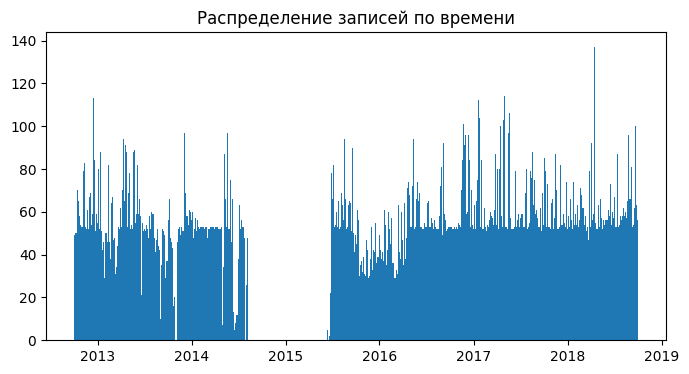

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(X_raw['date_time'], bins=1000)
plt.title("Распределение записей по времени")
print(f'Колличество идентичных записей: {X_raw.duplicated().sum()}')
plt.show()

При более внимательном изучении данных было выявлено, что присутвуют идентичные записи в один час, которые отличаются только погодой

2013-06-05 20\:00\:00 Был как дождь так и туман, При этом в значения трафика в соответвующих часах не отличаются, что может быть критично для реккурентных моделей

In [8]:
X_raw[6700:6708]

,holiday,temp,rain_1h,snow_1h,clouds_all,date_time,Clear,Clouds,Drizzle,Fog,Haze,Mist,Rain,Smoke,Snow,Squall,Thunderstorm
6700,0,286.69,0.57,0.0,92,2013-06-05 20:00:00,0,0,0,0,0,0,1,0,0,0,0
6701,0,286.69,0.57,0.0,92,2013-06-05 20:00:00,0,0,0,0,0,1,0,0,0,0,0
6702,0,286.48,0.25,0.0,90,2013-06-05 21:00:00,0,0,0,0,0,0,1,0,0,0,0
6703,0,286.48,0.25,0.0,90,2013-06-05 21:00:00,0,0,1,0,0,0,0,0,0,0,0
6704,0,286.26,0.25,0.0,92,2013-06-05 22:00:00,0,0,0,0,0,0,1,0,0,0,0
6705,0,286.26,0.25,0.0,92,2013-06-05 22:00:00,0,0,1,0,0,0,0,0,0,0,0
6706,0,285.93,0.38,0.0,92,2013-06-05 23:00:00,0,0,0,0,0,0,1,0,0,0,0
6707,0,285.93,0.38,0.0,92,2013-06-05 23:00:00,0,0,1,0,0,0,0,0,0,0,0


In [9]:
y_raw[6700:6708]

,traffic_volume
6700,2821
6701,2821
6702,2615
6703,2615
6704,1922
6705,1922
6706,1293
6707,1293


In [10]:
X_raw['traffic_volume'] = y_raw['traffic_volume']

df_clean = X_raw.groupby('date_time').max().reset_index()

y_raw = df_clean[['traffic_volume']]
X_raw = df_clean.drop(columns=['traffic_volume'])

In [11]:
X_raw

,date_time,holiday,temp,rain_1h,snow_1h,clouds_all,Clear,Clouds,Drizzle,Fog,Haze,Mist,Rain,Smoke,Snow,Squall,Thunderstorm
0,2012-10-02 09:00:00,0,288.28,0.0,0.0,40,0,1,0,0,0,0,0,0,0,0,0
1,2012-10-02 10:00:00,0,289.36,0.0,0.0,75,0,1,0,0,0,0,0,0,0,0,0
2,2012-10-02 11:00:00,0,289.58,0.0,0.0,90,0,1,0,0,0,0,0,0,0,0,0
3,2012-10-02 12:00:00,0,290.13,0.0,0.0,90,0,1,0,0,0,0,0,0,0,0,0
4,2012-10-02 13:00:00,0,291.14,0.0,0.0,75,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40570,2018-09-30 19:00:00,0,283.45,0.0,0.0,75,0,1,0,0,0,0,0,0,0,0,0
40571,2018-09-30 20:00:00,0,282.76,0.0,0.0,90,0,1,0,0,0,0,0,0,0,0,0
40572,2018-09-30 21:00:00,0,282.73,0.0,0.0,90,0,0,0,0,0,0,0,0,0,0,1
40573,2018-09-30 22:00:00,0,282.09,0.0,0.0,90,0,1,0,0,0,0,0,0,0,0,0


Колличество идентичных записей: 0


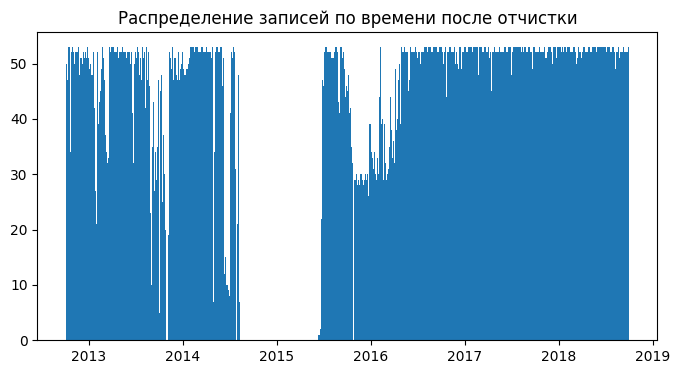

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(X_raw['date_time'], bins=1000)
plt.title("Распределение записей по времени после отчистки")
print(f'Колличество идентичных записей: {X_raw.duplicated().sum()}')
plt.show()

Так же пропуски могут плохо сказаться на обучение моделей. Колличество замеров наиболее близкое к равномерному начинается с середины 2016 года:

In [13]:
X_raw[(X_raw['date_time'].dt.year == 2016) & (X_raw['date_time'].dt.month == 5)]

,date_time,holiday,temp,rain_1h,snow_1h,clouds_all,Clear,Clouds,Drizzle,Fog,Haze,Mist,Rain,Smoke,Snow,Squall,Thunderstorm
19534,2016-05-01 00:00:00,0,280.75,0.0,0.0,90,0,0,0,0,0,0,1,0,0,0,0
19535,2016-05-01 01:00:00,0,280.02,0.0,0.0,90,0,1,0,0,0,0,0,0,0,0,0
19536,2016-05-01 02:00:00,0,279.48,0.0,0.0,90,0,1,0,0,0,0,0,0,0,0,0
19537,2016-05-01 03:00:00,0,279.02,0.0,0.0,90,0,1,0,0,0,0,0,0,0,0,0
19538,2016-05-01 04:00:00,0,278.56,0.0,0.0,90,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20249,2016-05-31 19:00:00,0,295.06,0.0,0.0,75,0,1,0,0,0,0,0,0,0,0,0
20250,2016-05-31 20:00:00,0,294.51,0.0,0.0,75,0,1,0,0,0,0,0,0,0,0,0
20251,2016-05-31 21:00:00,0,292.22,0.0,0.0,75,0,1,0,0,0,0,0,0,0,0,0
20252,2016-05-31 22:00:00,0,290.60,0.0,0.0,20,0,1,0,0,0,0,0,0,0,0,0


Принято решение оставить эти для обучения:

Количество данных после отчистки: 21075


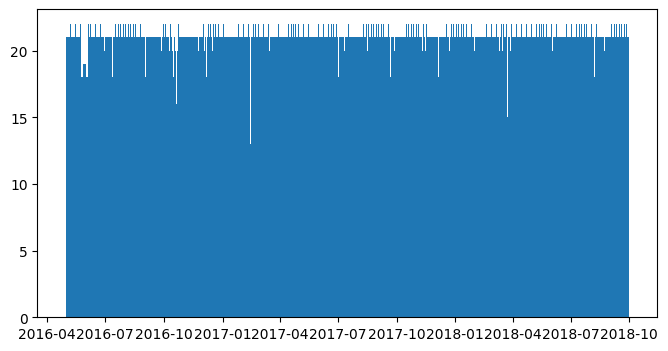

In [14]:
X = X_raw[19500:].reset_index(drop=True)
y = y_raw[19500:].reset_index(drop=True)
print(f'Количество данных после отчистки: {len(X)}')
plt.figure(figsize=(8, 4))
plt.hist(X['date_time'], bins=1000)
plt.show()

# Статистики

In [15]:
X.describe()

,date_time,temp,rain_1h,snow_1h,clouds_all,Clear,Clouds,Drizzle,Fog,Haze,Mist,Rain,Smoke,Snow,Squall,Thunderstorm
count,21075,21075.000000,21075.000000,21075.0,21075.000000,21075.000000,21075.000000,21075.00000,21075.000000,21075.000000,21075.000000,21075.000000,21075.000000,21075.000000,21075.000000,21075.000000
mean,2017-07-16 22:18:21.779359232,283.334371,0.516787,0.0,41.520047,0.350130,0.340024,0.05191,0.026572,0.034828,0.148043,0.143630,0.000569,0.069134,0.000047,0.031744
min,2016-04-29 14:00:00,243.390000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-12-08 09:30:00,274.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2017-07-17 14:00:00,285.970000,0.000000,0.0,40.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2018-02-22 17:30:00,293.345000,0.000000,0.0,90.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2018-09-30 23:00:00,310.070000,9831.300000,0.0,100.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,12.538411,67.723374,0.0,38.615900,0.477022,0.473728,0.22185,0.160832,0.183348,0.355151,0.350722,0.023856,0.253688,0.006888,0.175321


In [16]:
print(y.describe())
print('-------------')
print(y.median())

       traffic_volume
count    21075.000000
mean      3300.898553
std       1958.441210
min          0.000000
25%       1292.500000
50%       3494.000000
75%       4919.500000
max       7280.000000
-------------
traffic_volume    3494.0
dtype: float64


In [17]:
def get_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]

    return outliers

## Анализ распределений (трафик)

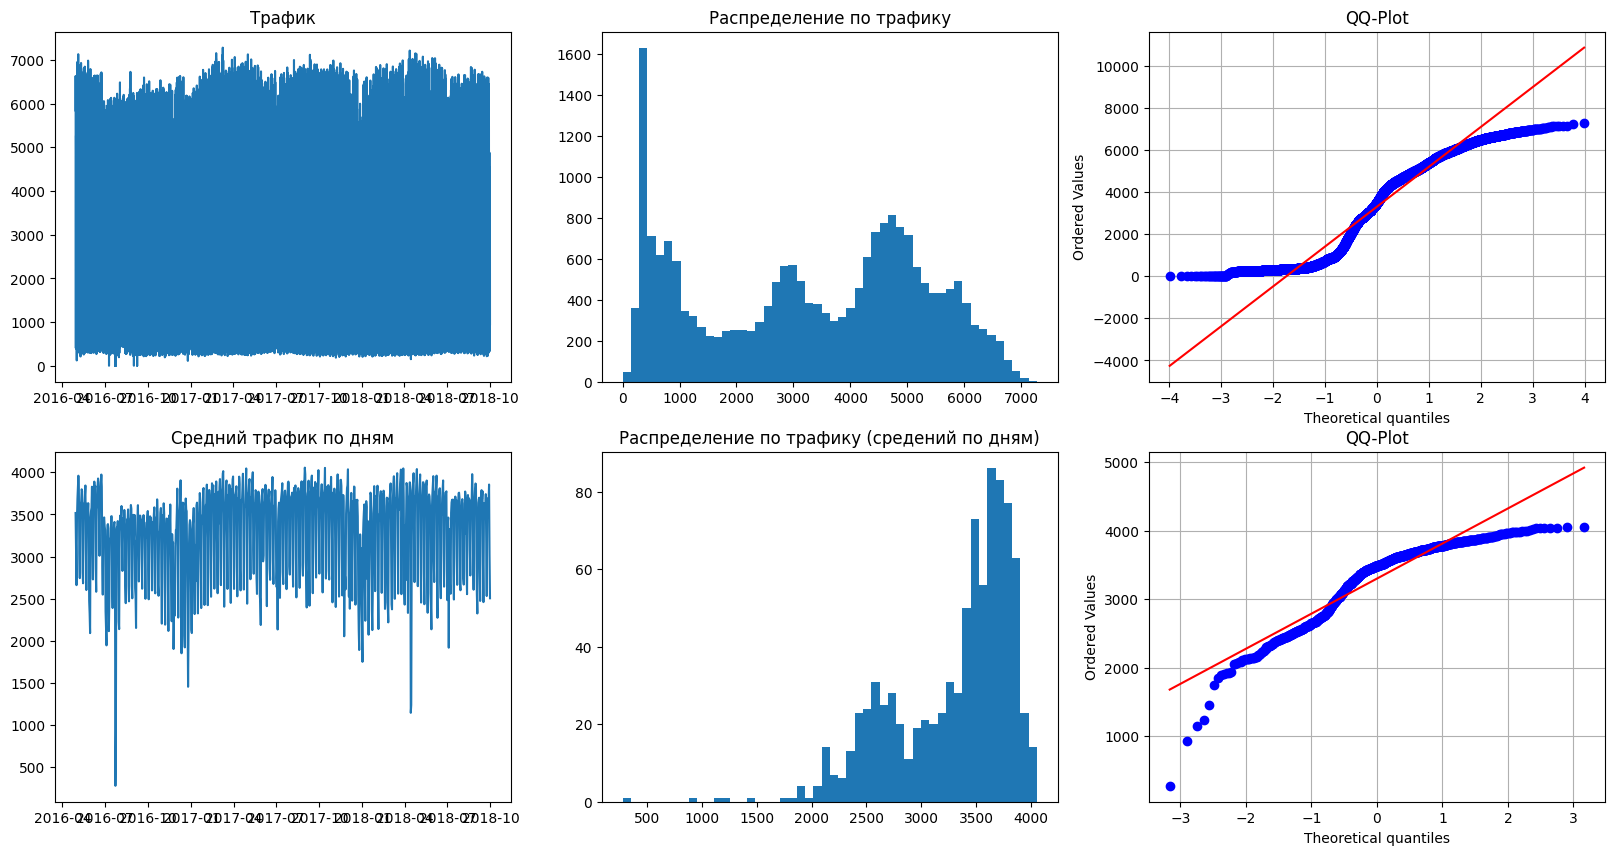

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

axes[0].set_title('Трафик')
axes[0].plot(X['date_time'], y['traffic_volume'])

axes[1].hist(y, bins=50)
axes[1].set_title('Распределение по трафику')

stats.probplot(y['traffic_volume'], dist="norm", plot=axes[2])
axes[2].set_title('QQ-Plot')
axes[2].grid(True)

traffic_per_day = y.groupby(X['date_time'].dt.date).mean()
axes[3].set_title('Средний трафик по дням')
axes[3].plot(traffic_per_day)

axes[4].hist(traffic_per_day, bins=50)
axes[4].set_title('Распределение по трафику (средений по дням)')

stats.probplot(traffic_per_day['traffic_volume'], dist="norm", plot=axes[5])
axes[5].set_title('QQ-Plot')
axes[5].grid(True)

plt.show()

##  Выявление выбросов по трафику

Кол-во выбросов по трафику: 0


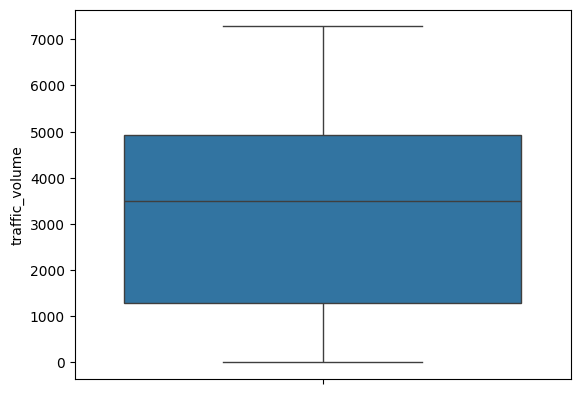

In [19]:
sns.boxplot(y['traffic_volume'])
outliers = get_outliers(y['traffic_volume'])
print(f"Кол-во выбросов по трафику: {len(outliers)}")

## Выявление выбросов в признаках

Кол-во выбросов в date_time: 0
Кол-во выбросов в holiday: 617
Кол-во выбросов в temp: 4
Кол-во выбросов в rain_1h: 696
Кол-во выбросов в snow_1h: 0
Кол-во выбросов в clouds_all: 0
Кол-во выбросов в Clear: 0
Кол-во выбросов в Clouds: 0
Кол-во выбросов в Drizzle: 1094
Кол-во выбросов в Fog: 560
Кол-во выбросов в Haze: 734
Кол-во выбросов в Mist: 3120
Кол-во выбросов в Rain: 3027
Кол-во выбросов в Smoke: 12
Кол-во выбросов в Snow: 1457
Кол-во выбросов в Squall: 1
Кол-во выбросов в Thunderstorm: 669


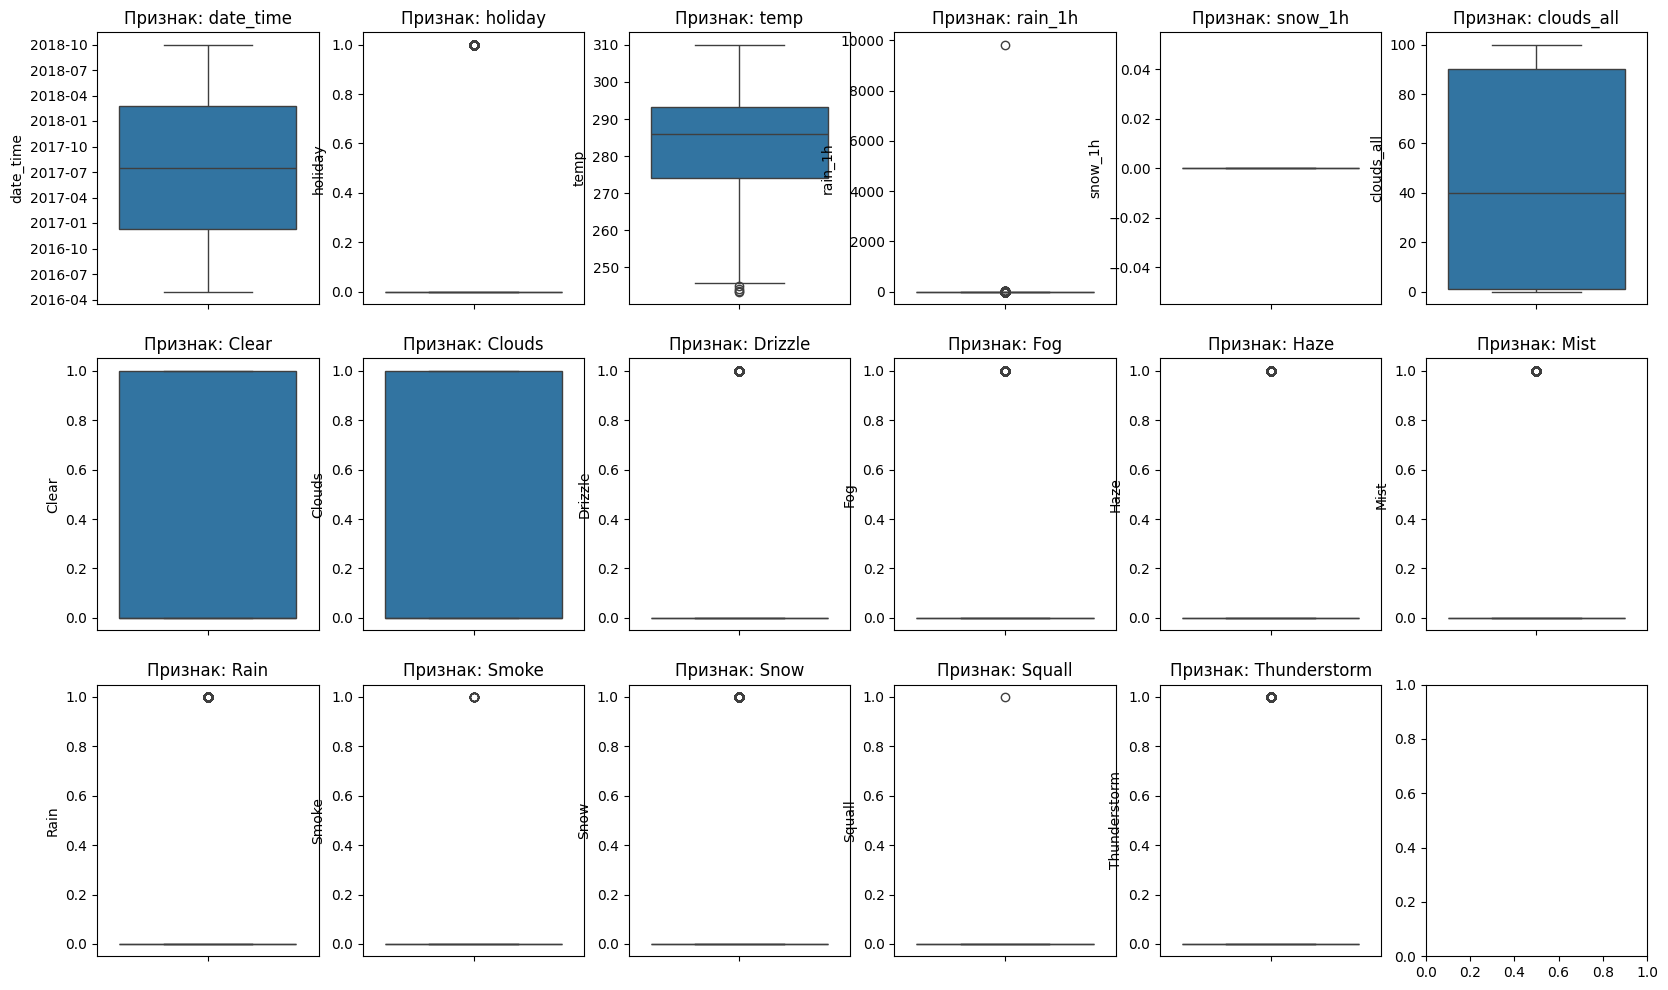

In [20]:
fig, axes = plt.subplots(3, 6, figsize=(20, 12))
axes = axes.flatten()

cols = X.columns
for ax, col in zip(axes, cols):
    sns.boxplot(X[col], ax=ax)
    outliers = get_outliers(X[col])
    print(f"Кол-во выбросов в {col}: {len(outliers)}")
    ax.set_title(f"Признак: {col}")

plt.show()

## Анализ распределений по признакам

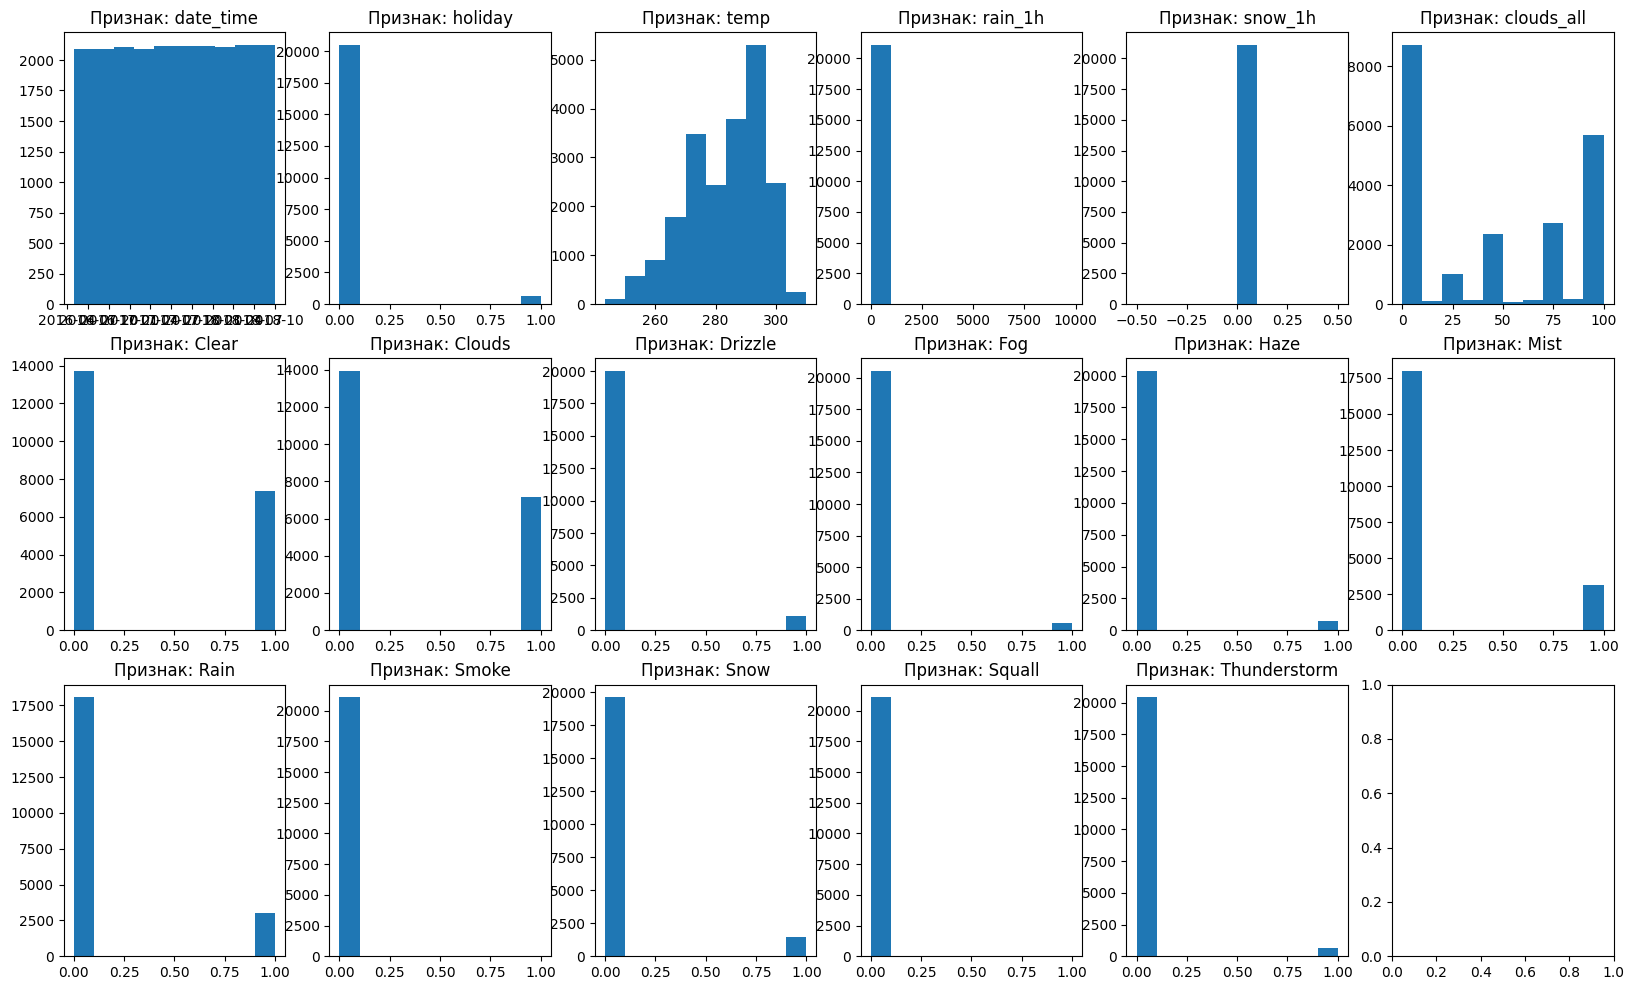

In [21]:
fig, axes = plt.subplots(3, 6, figsize=(20, 12))
axes = axes.flatten()

cols = X.columns
for ax, col in zip(axes, cols):
    ax.hist(X[col])
    ax.set_title(f"Признак: {col}")

plt.show()

# Визуализация временного ряда

## Декомпозиция на компоненты

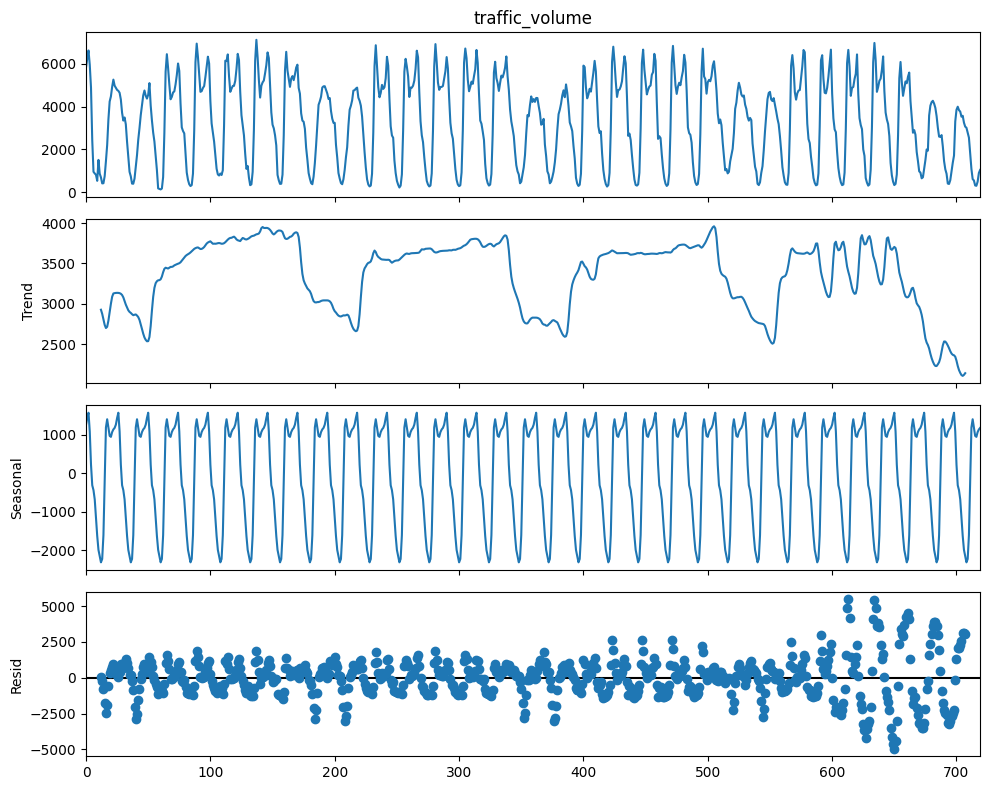

In [22]:
sample_data = y['traffic_volume'].head(24 * 30)

result = seasonal_decompose(sample_data, model='additive', period=24)

plt.rcParams.update({'figure.figsize': (10, 8)})
result.plot()
plt.show()

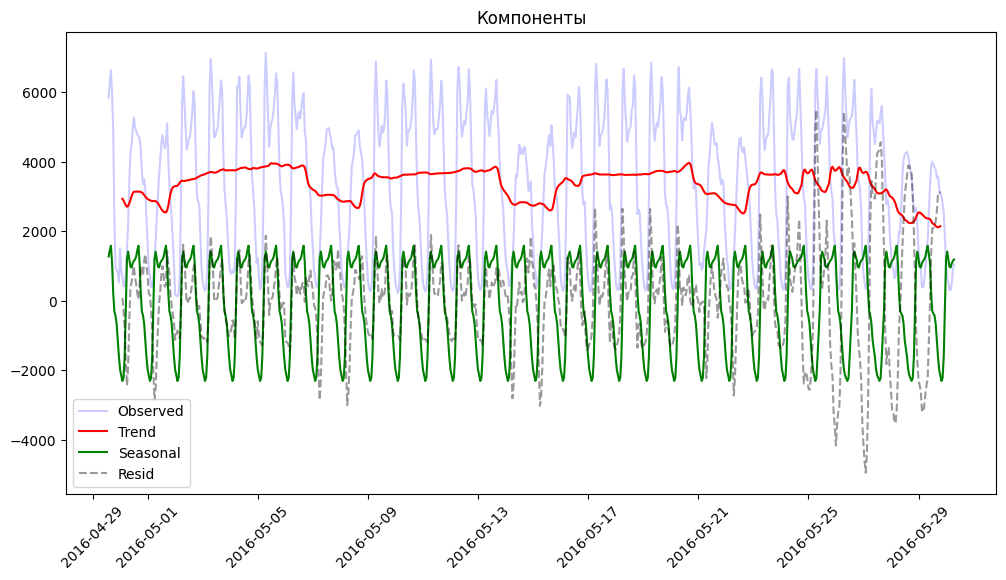

In [140]:
y_decomp = pd.DataFrame({
    'Observed': result.observed,
    'Trend': result.trend,
    'Seasonal': result.seasonal,
    'Resid': result.resid
})
date_time_month = X['date_time'].head(24 * 30)
y_observed = y_decomp['Observed']
y_trend = y_decomp['Trend']
y_seasonal = y_decomp['Seasonal']
y_resid = y_decomp['Resid']

plt.figure(figsize=(12, 6))

plt.plot(date_time_month, y_observed, color='blue', label='Observed', alpha=0.2)
plt.plot(date_time_month, y_trend, color='red', label='Trend')
plt.plot(date_time_month, y_seasonal, color='green', label='Seasonal')
plt.plot(date_time_month, y_resid, color='black', label='Resid', linestyle='--', alpha=0.4)
plt.xticks(rotation=45) 
plt.legend()
plt.title("Компоненты")
plt.show()

## Анализ автокорреляционной функции (ACF)

### Реализация из лекции

In [24]:
y_values = y['traffic_volume'].values
x_acf = y_values - y_values.mean()
c0 = (x_acf**2).mean()

max_lag_month = 24 * 30

acf_month = np.array([(x_acf[:len(x_acf) - lag] * x_acf[lag:]).mean() / c0 for lag in range(max_lag_month + 1)])

max_lag_week = 24 * 7

acf_week = np.array([(x_acf[:len(x_acf) - lag] * x_acf[lag:]).mean() / c0 for lag in range(max_lag_week + 1)])

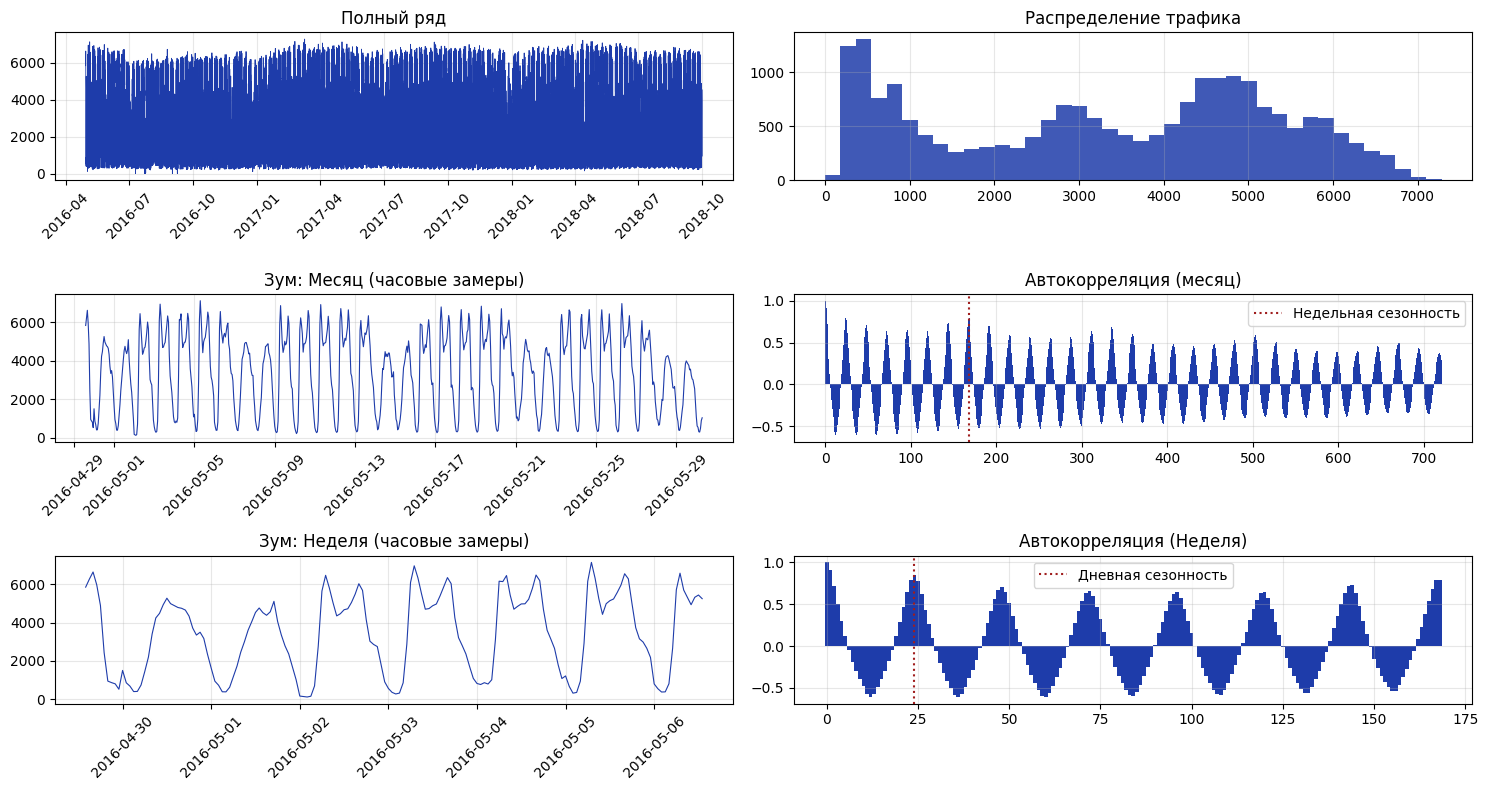

In [143]:
fig, ax = plt.subplots(3, 2, figsize=(15, 8))
ax[0,0].plot(X['date_time'], y_values, color='#1E3CAA', lw=0.6)
plt.setp(ax[0,0].get_xticklabels(), rotation=45)
ax[0,0].set_title('Полный ряд'); ax[0,0].grid(alpha=0.3)

ax[0,1].hist(y_values, bins=40, color='#1E3CAA', alpha=0.85)
ax[0,1].set_title('Распределение трафика'); ax[0,1].grid(alpha=0.3)

ax[1,0].plot(X['date_time'][:24 * 30], y_values[:24 * 30], color='#1E3CAA', lw=0.8)
plt.setp(ax[1,0].get_xticklabels(), rotation=45)
ax[1,0].set_title('Зум: Месяц (часовые замеры)'); ax[1,0].grid(alpha=0.3)

ax[1,1].bar(range(max_lag_month + 1), acf_month, color='#1E3CAA', width=1.0)
ax[1,1].axvline(24 * 7, color='#A01E1E', ls=':', label='Недельная сезонность')
ax[1,1].set_title('Автокорреляция (месяц)'); ax[1,1].legend(); ax[1,1].grid(alpha=0.3)

ax[2,0].plot(X['date_time'][:24 * 7], y_values[:24 * 7], color='#1E3CAA', lw=0.8)
plt.setp(ax[2,0].get_xticklabels(), rotation=45)
ax[2,0].set_title('Зум: Неделя (часовые замеры)'); ax[2,0].grid(alpha=0.3)

ax[2,1].bar(range(max_lag_week + 1), acf_week, color='#1E3CAA', width=1.0)
ax[2,1].axvline(24, color='#A01E1E', ls=':', label='Дневная сезонность')
ax[2,1].set_title('Автокорреляция (Неделя)'); ax[2,1].legend(); ax[2,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Библиотечная реализация

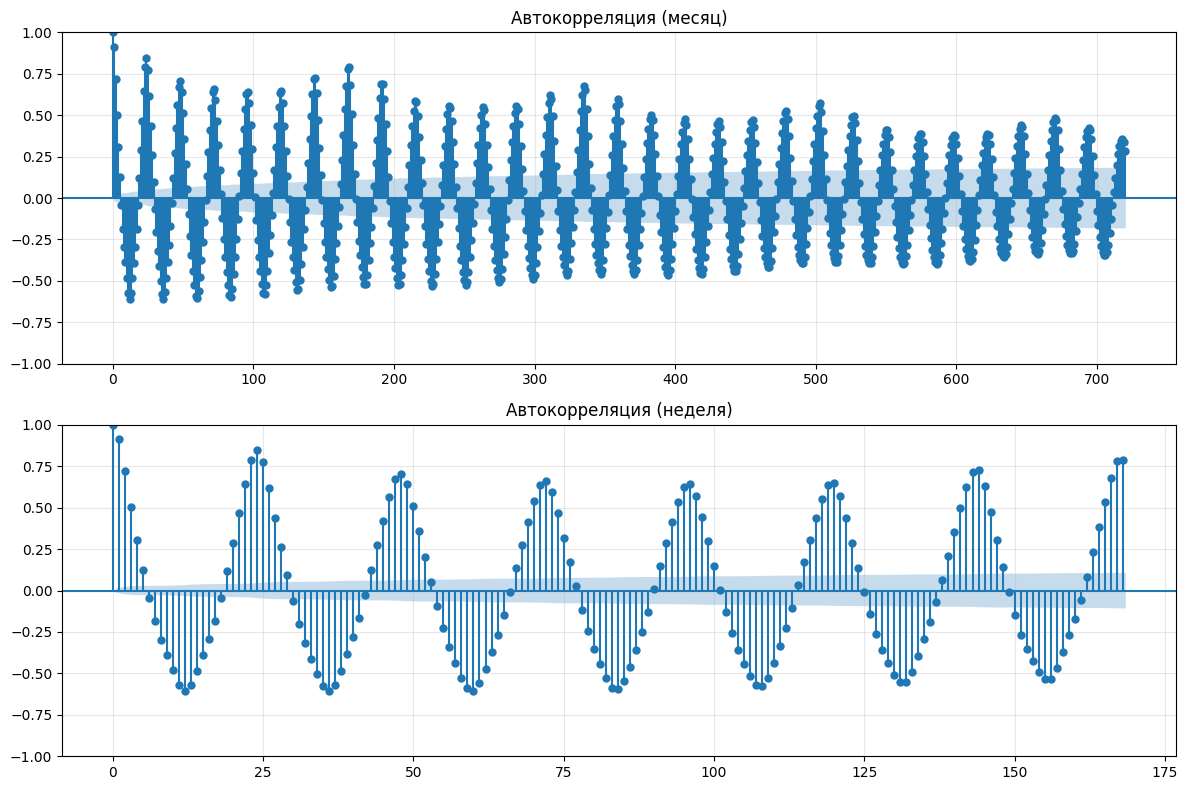

In [26]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(y_values, ax=ax[0], lags=24 * 30)
plot_acf(y_values, ax=ax[1], lags=24 * 7)

ax[0].set_title('Автокорреляция (месяц)'); ax[0].grid(alpha=0.3)
ax[1].set_title('Автокорреляция (неделя)'); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Анализ частной автокорреляционной функции (PACF)

### Ручная реализация 

In [27]:
y_values = y['traffic_volume'].values
x_pacf = y_values - y_values.mean()

max_lag_week_pacf = 24*7
pacf = [1.0]

for k in range(1, max_lag_week_pacf + 1):
    Y_target = x_pacf[k:]
    
    X_features = np.column_stack([x_pacf[k - i : len(x_pacf) - i] for i in range(1, k + 1)])

    coefficients, _, _, _ = np.linalg.lstsq(X_features, Y_target, rcond=None)
    pacf.append(coefficients[-1])

pacf = np.array(pacf)

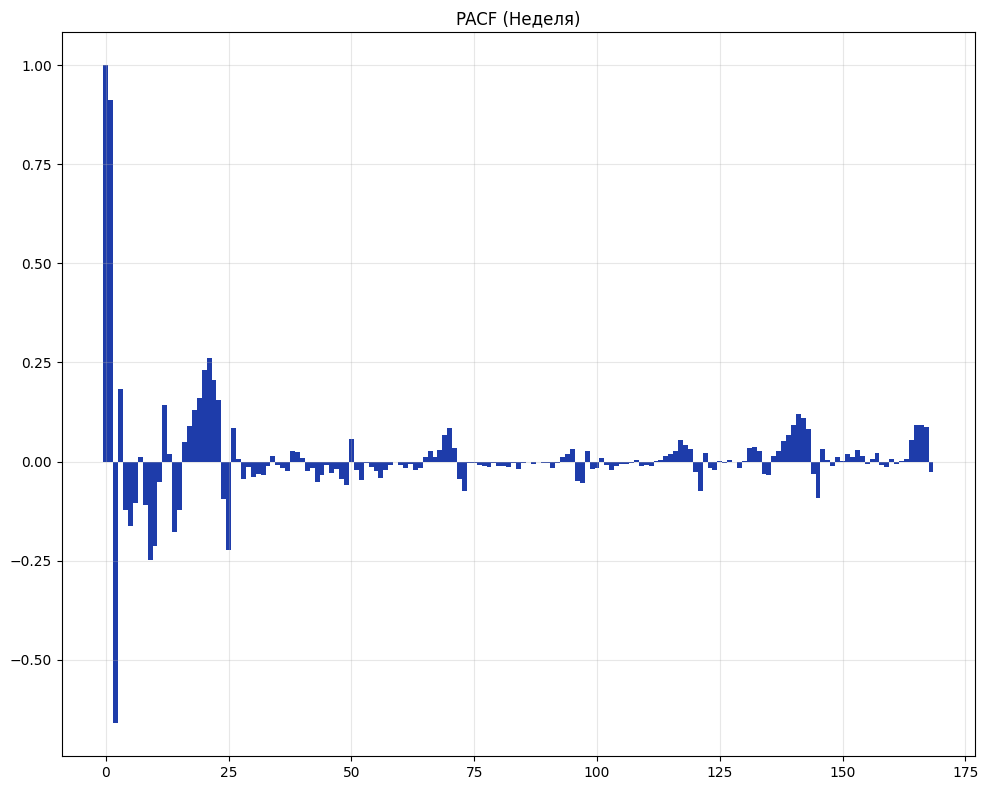

In [28]:
plt.bar(range(max_lag_week_pacf + 1), pacf, color='#1E3CAA', width=1.0)
plt.title('PACF (Неделя)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Библиотечная реализация

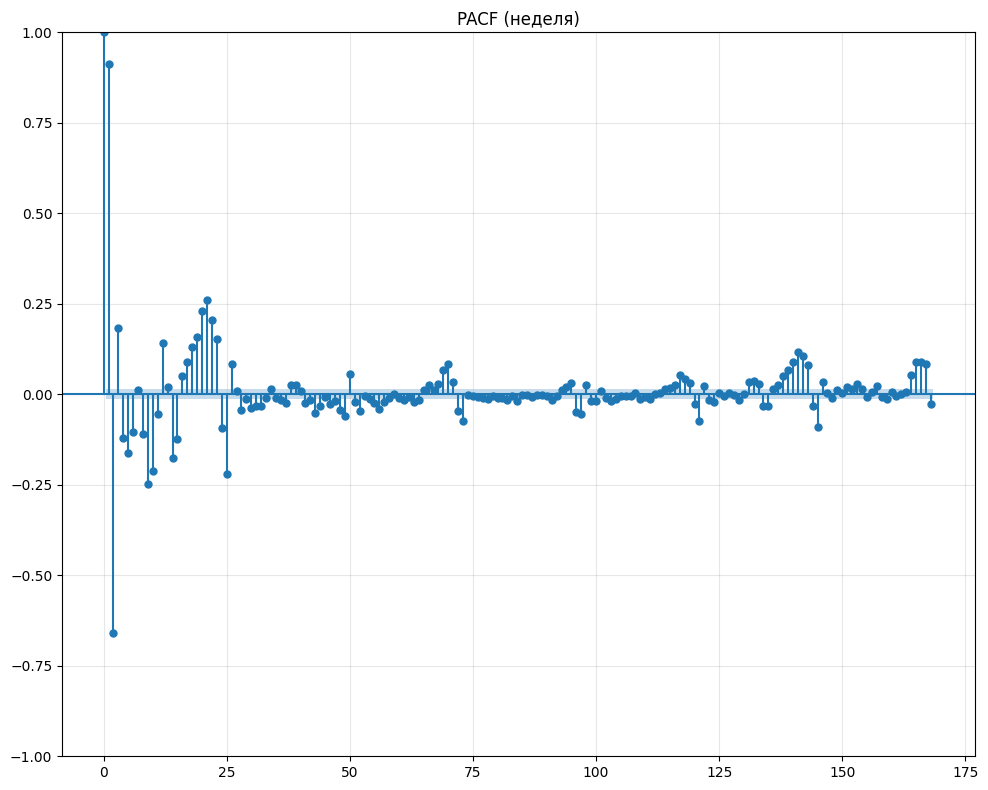

In [29]:
plot_pacf(y_values, lags=24 * 7)
plt.title('PACF (неделя)'); 
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Статистические тесты

## Тест Дики-Фуллера на стационарность

In [30]:
adf_result = adfuller(y['traffic_volume'])
print("--- ADF Test Results ---")
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Lags Used: {adf_result[2]}")
print(f"Number of Observations: {adf_result[3]}")

--- ADF Test Results ---
ADF Statistic: -18.6311539805495
p-value: 2.0575337975657863e-30
Lags Used: 46
Number of Observations: 21028


**Вывод**

Тест позволяет говорить о **стационарности ряда**

Однако визуальный анализ и декомпозиция на компоненты показывают наличие суточной сезонности и колебания тренда

## Тест Шапиро-Уилка на нормальность остатков
Два теста:
1) остатки (шум) полученные после декомпозиции ряда на компоненты
2) остатки (ошибки) полученные от наивной модели (трафик в прошлый день)

In [31]:
residuals = y_resid.dropna()

shapiro_wilk_res = stats.shapiro(residuals)
print("--- Shapiro Wilk Test Results ---")
print(f"Shapiro Wilk Statistic: {shapiro_wilk_res[0]}")
print(f"p-value: {shapiro_wilk_res[1]}")

--- Shapiro Wilk Test Results ---
Shapiro Wilk Statistic: 0.966825829601118
p-value: 1.880475305404168e-11


In [32]:
y_naive = y.shift(24)
residuals = y - y_naive
residuals = residuals.dropna()
sample = residuals.sample(n=4000, random_state=42)

shapiro_wilk_res = stats.shapiro(sample)
print("--- Shapiro Wilk Test Results ---")
print(f"Shapiro Wilk Statistic: {shapiro_wilk_res[0]}")
print(f"p-value: {shapiro_wilk_res[1]}")

--- Shapiro Wilk Test Results ---
Shapiro Wilk Statistic: 0.7989678021548811
p-value: 3.449765427833948e-57


**Вывод**: В обоих случаях гипотеза о нормальности остатков **отклоняется**. Распределение отличается от нормального

## Тест Льюнга-Бокса на автокорреляцию остатков
Два теста:
1) остатки (шум) полученные после декомпозиции ряда на компоненты
2) остатки (ошибки) полученные от наивной модели (трафик в прошлый день)

In [33]:
residuals = y_resid.dropna()

lb_result = acorr_ljungbox(residuals, lags=[24], return_df=True)
print(lb_result)

        lb_stat  lb_pvalue
24  3848.359066        0.0


In [34]:
y_naive = y.shift(24)
residuals = y - y_naive
residuals = residuals.dropna()

lb_result = acorr_ljungbox(residuals, lags=[24], return_df=True)
print(lb_result)

         lb_stat  lb_pvalue
24  26134.275797        0.0


**Вывод**: В обоих случаях между остатками наблюдаются зависимости, есть скрытые паттерны

# Генерация признаков

## Лаговые признаки

In [35]:
# Простые лаги 1-24
for lag in range(1, 25):
    X[f'traffic_lag_{lag}'] = y.shift(lag)

# Сезонные лаги - неделя и месяц (дневной лаг уже есть)
X[f'traffic_lag_week'] = y.shift(24*7)
X[f'traffic_lag_month'] = y.shift(24*30)

# Дифференциальные лаги
X[f'traffic_lag_d1'] = y['traffic_volume'].shift(1).diff(1)
X[f'traffic_lag_d2'] = y['traffic_volume'].shift(1).diff(2)

# Логарифмические лаги
for lag in range(1, 11):
    X[f'traffic_ln_lag_{lag}'] = np.log1p(X[f'traffic_lag_{lag}'])

# Лаги по погоде
weather_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
for col in weather_cols:
    X[f'{col}_lag_1h'] = X[col].shift(1)
    X[f'{col}_lag_2h'] = X[col].shift(2)
    X[f'{col}_lag_24h'] = X[col].shift(24)

## Скользящие статистики

In [36]:
rolling_features = {}
for w in [3, 5, 12, 24]:
    rolling_features[f'traffic_roll_mean_{w}'] = y['traffic_volume'].shift(1).rolling(window=w).mean()
    rolling_features[f'traffic_roll_median_{w}'] = y['traffic_volume'].shift(1).rolling(window=w).median()
    rolling_features[f'traffic_roll_std_{w}'] = y['traffic_volume'].shift(1).rolling(window=w).std()
    rolling_features[f'traffic_roll_min_{w}'] = y['traffic_volume'].shift(1).rolling(window=w).min()
    rolling_features[f'traffic_roll_max_{w}'] = y['traffic_volume'].shift(1).rolling(window=w).max()
    rolling_features[f'traffic_rolling_range_{w}'] = y['traffic_volume'].shift(1).rolling(window=w).max() - y['traffic_volume'].shift(1).rolling(window=w).min()
    rolling_features[f'traffic_roll_skew_{w}'] = y['traffic_volume'].shift(1).rolling(window=w).skew()
    rolling_features[f'traffic_roll_kurt_{w}'] = y['traffic_volume'].shift(1).rolling(window=w).kurt()
    
    
    rolling_features[f'temp_roll_mean_{w}'] = X['temp'].shift(1).rolling(window=w).mean()
    rolling_features[f'temp_roll_roll_std_{w}'] = X['temp'].shift(1).rolling(window=w).std()
    rolling_features[f'temp_roll_roll_min_{w}'] = X['temp'].shift(1).rolling(window=w).min()
    rolling_features[f'temp_roll_roll_max_{w}'] = X['temp'].shift(1).rolling(window=w).max()

df_roll_featch = pd.DataFrame(rolling_features)

X = pd.concat([X, df_roll_featch], axis=1)

## Экспоненциальное скользящее среднее

In [37]:
alphas = [0.1, 0.3, 0.5, 0.7, 0.8]
ema_alpha_features = {}

for a in alphas:
    ema_alpha_features[f'traffic_ema_alpha_{a}'] = y['traffic_volume'].shift(1).ewm(alpha=a, adjust=False).mean()
    ema_alpha_features[f'temp_ema_alpha_{a}'] = X['temp'].shift(1).ewm(alpha=a, adjust=False).mean()

for a in alphas:
    ema1 = y['traffic_volume'].shift(1).ewm(alpha=a, adjust=False).mean()
    ema2 = ema1.ewm(alpha=a, adjust=False).mean()
    ema_alpha_features[f'traffic_dema_alpha_{a}'] = 2 * ema1 - ema2

    tema1 = X['temp'].shift(1).ewm(alpha=a, adjust=False).mean()
    tema2 = tema1.ewm(alpha=a, adjust=False).mean()
    ema_alpha_features[f'temp_dema_alpha_{a}'] = 2 * tema1 - tema2

for a in alphas:
    ema1 = y['traffic_volume'].shift(1).ewm(alpha=a, adjust=False).mean()
    ema2 = ema1.ewm(alpha=a, adjust=False).mean()
    ema3 = ema2.ewm(alpha=a, adjust=False).mean()
    ema_alpha_features[f'traffic_tema_alpha_{a}'] = 3 * ema1 - 3 * ema2 + ema3

    tema1 = X['temp'].shift(1).ewm(alpha=a, adjust=False).mean()
    tema2 = tema1.ewm(alpha=a, adjust=False).mean()
    tema3 = tema2.ewm(alpha=a, adjust=False).mean()
    ema_alpha_features[f'temp_tema_alpha_{a}'] = 3 * tema1 - 3 * tema2 + tema3

df_ema = pd.DataFrame(ema_alpha_features)

X = pd.concat([X, df_ema], axis=1)

## Технические индикаторы

In [38]:
for w in [12, 24, 168]:
    X[f'rsi_{w}'] = ta.momentum.rsi(y['traffic_volume'].shift(1), window=w)

for w in [1, 6, 12, 24, 168]:
    X[f'roc_{w}'] = ta.momentum.roc(y['traffic_volume'].shift(1), window=w)

macd1 = ta.trend.MACD(y['traffic_volume'].shift(1), window_fast=12, window_slow=26, window_sign=9)
X['macd_short'] = macd1.macd()
X['macd_sign_short'] = macd1.macd_signal()

macd2 = ta.trend.MACD(y['traffic_volume'].shift(1), window_fast=24, window_slow=168, window_sign=24)
X['macd_long'] = macd2.macd()
X['macd_long_hist'] = macd2.macd_diff()

bb = ta.volatility.BollingerBands(y['traffic_volume'].shift(1), window=24, window_dev=2)
X['bb_high'] = bb.bollinger_hband()
X['bb_mid'] = bb.bollinger_mavg()
X['bb_low'] = bb.bollinger_lband()

## Временные признаки

In [39]:
X['hour'] = X['date_time'].dt.hour

day_of_week_onehot = pd.get_dummies(X['date_time'].dt.day_name(), dtype=int)
X = pd.concat([X, day_of_week_onehot], axis=1)

X['day'] = X['date_time'].dt.day

month_onehot = pd.get_dummies(X['date_time'].dt.month_name(), dtype=int)
X = pd.concat([X, month_onehot], axis=1)

X['quarter'] = X['date_time'].dt.quarter

X['dayofyear'] = X['date_time'].dt.dayofyear

X['hour_sin'] = np.sin(2 * np.pi * X['hour'] / 24)
X['hour_cos'] = np.cos(2 * np.pi * X['hour'] / 24)

X['day_sin'] = np.sin(2 * np.pi * X['date_time'].dt.dayofweek / 7)
X['day_cos'] = np.cos(2 * np.pi * X['date_time'].dt.dayofweek / 7)

X['month_sin'] = np.sin(2 * np.pi * X['date_time'].dt.month / 12)
X['month_cos'] = np.cos(2 * np.pi * X['date_time'].dt.month / 12)

X['dayofyear_sin'] = np.sin(2 * np.pi * X['dayofyear'] / 365)
X['dayofyear_cos'] = np.cos(2 * np.pi * X['dayofyear'] / 365)

## Статистические и математические признаки

### ACF

In [40]:
acf_features = {}
pacf_features = {}

for lag in [1, 2, 3, 6, 12]:    
    acf_features[f'traffic_rolling_acf_lag_{lag}'] = (
        y['traffic_volume'].shift(1).rolling(window=24)
        .corr(y['traffic_volume'].shift(1 + lag))
    )
    acf_features[f'temp_rolling_acf_lag_{lag}'] = (
        X['temp'].shift(1).rolling(window=24)
        .corr(X['temp'].shift(1 + lag))
    )

df_acf = pd.DataFrame(acf_features)

X = pd.concat([X, df_acf], axis=1)

### Дополнительные статистики

In [41]:
rolling_extra = {}
for w in [3, 5, 12, 24]:
    rolled = y['traffic_volume'].shift(1).rolling(window=w)
    
    rolling_extra[f'traffic_cv_{w}'] = rolled.std() / (rolled.mean() + 1e-8)
    
    rolling_extra[f'traffic_energy_{w}'] = rolled.apply(lambda x: np.sum(x**2), raw=True)
    
    rolling_extra[f'traffic_zero_cross_{w}'] = rolled.apply(
        lambda x: np.sum(np.diff(np.sign(x - x.mean())) != 0), raw=True
    )
    
    def count_extrema(x):
        if len(x) < 3:
            return 0
        return np.sum((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:])) + \
               np.sum((x[1:-1] < x[:-2]) & (x[1:-1] < x[2:]))
    
    rolling_extra[f'traffic_extrema_{w}'] = rolled.apply(count_extrema, raw=True)

X = pd.concat([X, pd.DataFrame(rolling_extra)], axis=1)

### Комплексные составные признаки

In [42]:
X['bb_position'] = (y['traffic_volume'].shift(1) - X['bb_low']) / (X['bb_high'] - X['bb_low'] + 1e-8)
X['bb_width'] = (X['bb_high'] - X['bb_low']) / (X['bb_mid'] + 1e-8)

for w in [3, 5, 12, 24]:
    ma = y['traffic_volume'].shift(1).rolling(window=w).mean()
    X[f'traffic_dist_ma_{w}'] = y['traffic_volume'].shift(1) - ma
    X[f'traffic_dist_ma_pct_{w}'] = (y['traffic_volume'].shift(1) - ma) / (ma + 1e-8)

for w in [24, 168]:
    ma = y['traffic_volume'].shift(1).rolling(window=w).mean()
    roll_std  = y['traffic_volume'].shift(1).rolling(window=w).std()
    X[f'traffic_zscore_{w}'] = (y['traffic_volume'].shift(1) - ma) / (roll_std + 1e-8)

for w1, w2 in [(3, 12), (3, 24), (12, 24)]:
    ma1 = y['traffic_volume'].shift(1).rolling(window=w1).mean()
    ma2 = y['traffic_volume'].shift(1).rolling(window=w2).mean()
    X[f'traffic_ma_ratio_{w1}_{w2}'] = ma1 / (ma2 + 1e-8)

### Показатель Херста

In [43]:
def hurst_exponent(ts, max_lag=20):
    lags = range(2, max_lag)
    tau = [np.std(ts[lag:] - ts[:-lag]) for lag in lags]
    if len(tau) == 0 or np.std(np.log(lags)) == 0:
        return np.nan
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]

X['hurst_24'] = y['traffic_volume'].shift(1).rolling(window=48).apply(hurst_exponent, raw=True)
X['hurst_168'] = y['traffic_volume'].shift(1).rolling(window=336).apply(hurst_exponent, raw=True)

### Спектральные признаки

In [44]:
def dominant_freq_features(x):
    fft_vals = np.abs(np.fft.rfft(x))
    freqs = np.fft.rfftfreq(len(x))
    
    dom_freq = freqs[np.argmax(fft_vals[1:]) + 1]
    
    spectral_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-8)

    psd = fft_vals ** 2
    psd_norm = psd / (np.sum(psd) + 1e-8)
    spectral_entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-8))
    
    return dom_freq, spectral_centroid, spectral_entropy
    
results = y['traffic_volume'].shift(1).rolling(window=24).apply(
    lambda x: dominant_freq_features(x)[0], raw=True
)
X['spectral_dom_freq_24'] = results

X['spectral_centroid_24'] = y['traffic_volume'].shift(1).rolling(window=24).apply(
    lambda x: dominant_freq_features(x)[1], raw=True
)
X['spectral_entropy_24'] = y['traffic_volume'].shift(1).rolling(window=24).apply(
    lambda x: dominant_freq_features(x)[2], raw=True
)

## Отчистка от NaN после отбора признаков

In [45]:
X

,date_time,holiday,temp,rain_1h,snow_1h,clouds_all,Clear,Clouds,Drizzle,Fog,...,traffic_zscore_24,traffic_zscore_168,traffic_ma_ratio_3_12,traffic_ma_ratio_3_24,traffic_ma_ratio_12_24,hurst_24,hurst_168,spectral_dom_freq_24,spectral_centroid_24,spectral_entropy_24
0,2016-04-29 14:00:00,0,286.27,0.0,0.0,20,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-04-29 15:00:00,0,287.05,0.0,0.0,20,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-04-29 16:00:00,0,287.62,0.0,0.0,20,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-04-29 17:00:00,0,288.21,0.0,0.0,20,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-04-29 18:00:00,0,288.32,0.0,0.0,20,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21070,2018-09-30 19:00:00,0,283.45,0.0,0.0,75,0,1,0,0,...,0.784988,0.279549,1.128203,1.503321,1.332492,0.337832,0.274515,0.041667,0.058079,0.460185
21071,2018-09-30 20:00:00,0,282.76,0.0,0.0,90,0,1,0,0,...,0.532027,0.076616,1.006299,1.419264,1.410380,0.352856,0.275532,0.041667,0.057423,0.460805
21072,2018-09-30 21:00:00,0,282.73,0.0,0.0,90,0,0,0,0,...,0.048983,-0.305777,0.874574,1.265038,1.446461,0.356598,0.276060,0.041667,0.060601,0.469770
21073,2018-09-30 22:00:00,0,282.09,0.0,0.0,90,0,1,0,0,...,-0.336983,-0.617312,0.733617,1.057698,1.441757,0.353895,0.275718,0.041667,0.058324,0.482803


In [46]:
nan_counts = X.isna().sum()
print('Топ столбцов с NaN')
print(nan_counts[nan_counts > 0].sort_values(ascending=False).head(20))

numeric_X = X.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_X).sum()
print('Топ столбцов с inf')
print(inf_counts[inf_counts > 0].sort_values(ascending=False).head(20))


Топ столбцов с NaN
traffic_roll_kurt_3           21075
traffic_lag_month               720
hurst_168                       336
macd_long_hist                  191
roc_168                         169
traffic_zscore_168              168
traffic_lag_week                168
macd_long                       168
rsi_168                         167
temp_rolling_acf_lag_12          57
temp_rolling_acf_lag_6           49
hurst_24                         48
temp_rolling_acf_lag_3           47
temp_rolling_acf_lag_2           47
temp_rolling_acf_lag_1           45
traffic_rolling_acf_lag_12       36
macd_sign_short                  34
traffic_rolling_acf_lag_6        30
traffic_rolling_acf_lag_3        27
macd_short                       26
dtype: int64
Топ столбцов с inf
temp_rolling_acf_lag_12    11
temp_rolling_acf_lag_6      7
temp_rolling_acf_lag_3      3
roc_1                       2
roc_6                       2
roc_12                      2
roc_24                      2
roc_168            

In [47]:
X = X.drop(columns=["traffic_roll_kurt_3"])

In [109]:
df_final = pd.concat([X, y], axis=1)

df_final = df_final.dropna(subset=['traffic_lag_month']).reset_index(drop=True)

y_final = df_final['traffic_volume']
X_final = df_final.drop(columns=['traffic_volume'])

print(f"Cтрок очистки: {len(X_final)}")

Cтрок очистки: 20355


In [110]:
nan_counts = X_final.isna().sum()
print(nan_counts[nan_counts > 0].sort_values(ascending=False).head(20))

numeric_X = X_final.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_X).sum()
print(inf_counts[inf_counts > 0].sort_values(ascending=False).head(20))

temp_rolling_acf_lag_2     21
temp_rolling_acf_lag_12    21
temp_rolling_acf_lag_1     20
temp_rolling_acf_lag_3     20
temp_rolling_acf_lag_6     19
dtype: int64
temp_rolling_acf_lag_12    11
temp_rolling_acf_lag_6      7
temp_rolling_acf_lag_3      3
roc_1                       2
roc_6                       2
roc_12                      2
roc_24                      2
roc_168                     2
temp_rolling_acf_lag_1      1
temp_rolling_acf_lag_2      1
dtype: int64


In [111]:
X_final

,date_time,holiday,temp,rain_1h,snow_1h,clouds_all,Clear,Clouds,Drizzle,Fog,...,traffic_zscore_24,traffic_zscore_168,traffic_ma_ratio_3_12,traffic_ma_ratio_3_24,traffic_ma_ratio_12_24,hurst_24,hurst_168,spectral_dom_freq_24,spectral_centroid_24,spectral_entropy_24
0,2016-05-30 08:00:00,1,290.20,0.0,0.0,75,0,0,0,0,...,-0.832113,-1.039073,0.629088,0.374981,0.596070,0.247743,0.225121,0.041667,0.044684,0.488093
1,2016-05-30 10:00:00,1,295.51,0.0,0.0,75,0,1,0,0,...,-0.680473,-0.915858,0.936083,0.491561,0.525125,0.254470,0.225247,0.041667,0.043199,0.479380
2,2016-05-30 11:00:00,1,297.56,0.0,0.0,75,0,1,0,0,...,0.302552,-0.222730,1.459086,0.738851,0.506379,0.240738,0.224330,0.041667,0.062935,0.475021
3,2016-05-30 12:00:00,1,298.85,0.0,0.0,40,0,1,0,0,...,0.714822,0.092891,2.009479,1.039425,0.517261,0.225802,0.223539,0.041667,0.038328,0.450246
4,2016-05-30 14:00:00,1,300.32,0.0,0.0,40,0,1,0,0,...,0.941675,0.256838,2.362630,1.368910,0.579401,0.224367,0.223382,0.041667,0.038439,0.452449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20350,2018-09-30 19:00:00,0,283.45,0.0,0.0,75,0,1,0,0,...,0.784988,0.279549,1.128203,1.503321,1.332492,0.337832,0.274515,0.041667,0.058079,0.460185
20351,2018-09-30 20:00:00,0,282.76,0.0,0.0,90,0,1,0,0,...,0.532027,0.076616,1.006299,1.419264,1.410380,0.352856,0.275532,0.041667,0.057423,0.460805
20352,2018-09-30 21:00:00,0,282.73,0.0,0.0,90,0,0,0,0,...,0.048983,-0.305777,0.874574,1.265038,1.446461,0.356598,0.276060,0.041667,0.060601,0.469770
20353,2018-09-30 22:00:00,0,282.09,0.0,0.0,90,0,1,0,0,...,-0.336983,-0.617312,0.733617,1.057698,1.441757,0.353895,0.275718,0.041667,0.058324,0.482803


In [112]:
X_final = X_final.replace([np.inf, -np.inf], np.nan)
X_final = X_final.ffill()

print("Осталось NaN:", X_final.isna().sum().sum())
print("Осталось inf:", np.isinf(X_final).sum().sum())

Осталось NaN: 0
Осталось inf: 0


C:\Users\gromt\AppData\Local\Temp\ipykernel_6276\646857591.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_final = X_final.replace([np.inf, -np.inf], np.nan)


# Feature selection

In [113]:
X_step0 = X_final.drop(columns=['date_time'])
X_date_time = X_final['date_time']
print(f"Признаков до отбора: {X_step0.shape[1]}")

Признаков до отбора: 235


### Признаки с дисперсией близкой к 0

In [114]:
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_step0)

low_var_mask = selector_var.get_support()
dropped_low_var = X_step0.columns[~low_var_mask].tolist()

X_step1 = X_step0.loc[:, low_var_mask]

print(f"Удалено признаков: {len(dropped_low_var)}")
print(f"Осталось признаков: {X_step1.shape[1]}")
print(f"Удаленные: {dropped_low_var}")

Удалено признаков: 15
Осталось признаков: 220
Удаленные: ['snow_1h', 'Smoke', 'Squall', 'snow_1h_lag_1h', 'snow_1h_lag_2h', 'snow_1h_lag_24h', 'traffic_rolling_acf_lag_1', 'temp_rolling_acf_lag_1', 'traffic_rolling_acf_lag_2', 'traffic_cv_24', 'hurst_24', 'hurst_168', 'spectral_dom_freq_24', 'spectral_centroid_24', 'spectral_entropy_24']


### Высоко скоррелированные признаки

Удалено признаков: 75
Осталось признаков: 145


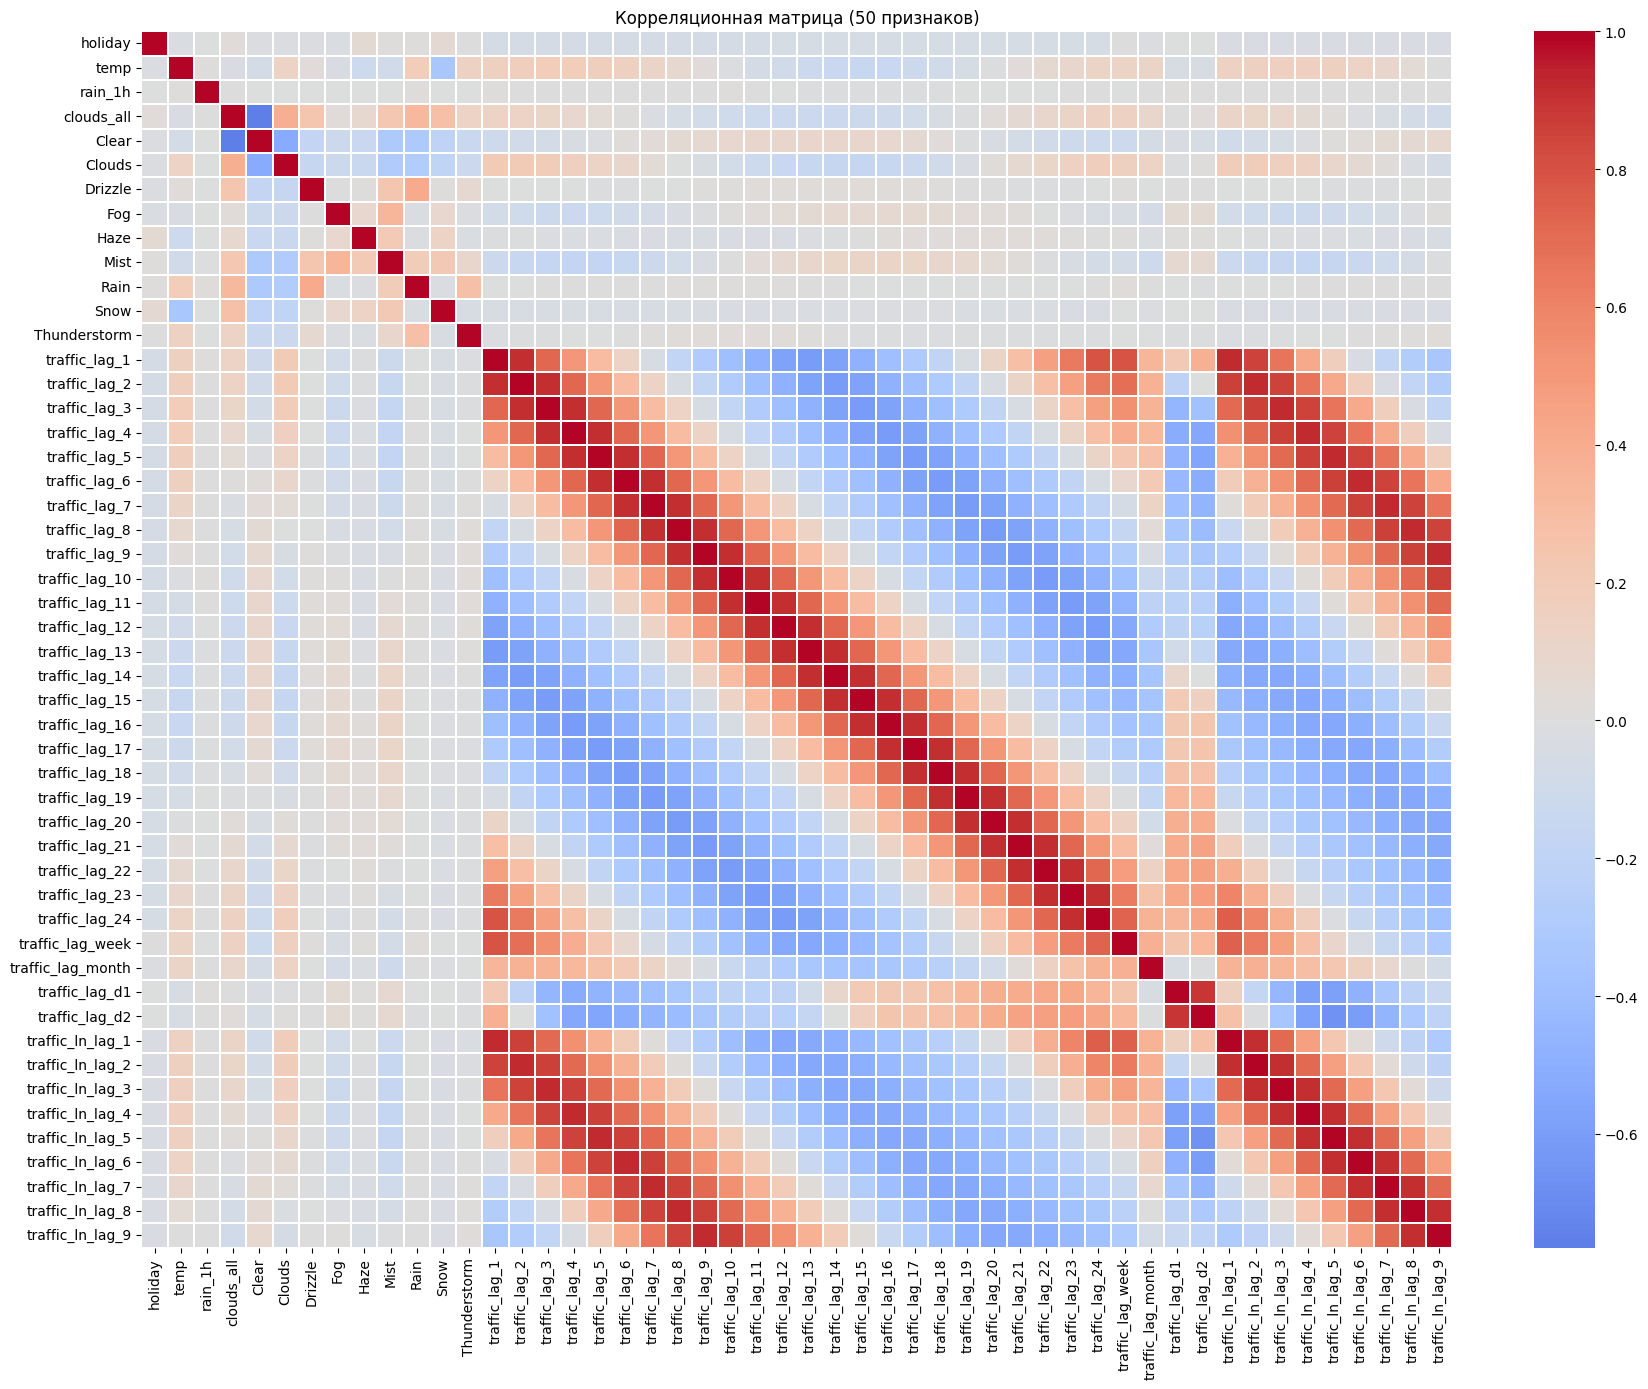

In [115]:
def drop_high_corr(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    to_drop = [
        col for col in upper.columns
        if any(upper[col] > threshold)
    ]
    return df.drop(columns=to_drop), to_drop

X_step2, dropped_corr = drop_high_corr(X_step1, threshold=0.95)

print(f"Удалено признаков: {len(dropped_corr)}")
print(f"Осталось признаков: {X_step2.shape[1]}")

sample_cols = X_step2.columns[:50]
corr_sample = X_step2[sample_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_sample, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True,
            linewidths=0.3, annot=False)
plt.title("Корреляционная матрица (50 признаков)")
plt.tight_layout()
plt.show()

### Случайный лес для отбора по важности для модели

In [116]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_step2, y_final)

importances = pd.Series(rf.feature_importances_, index=X_step2.columns)
importances = importances.sort_values(ascending=False)

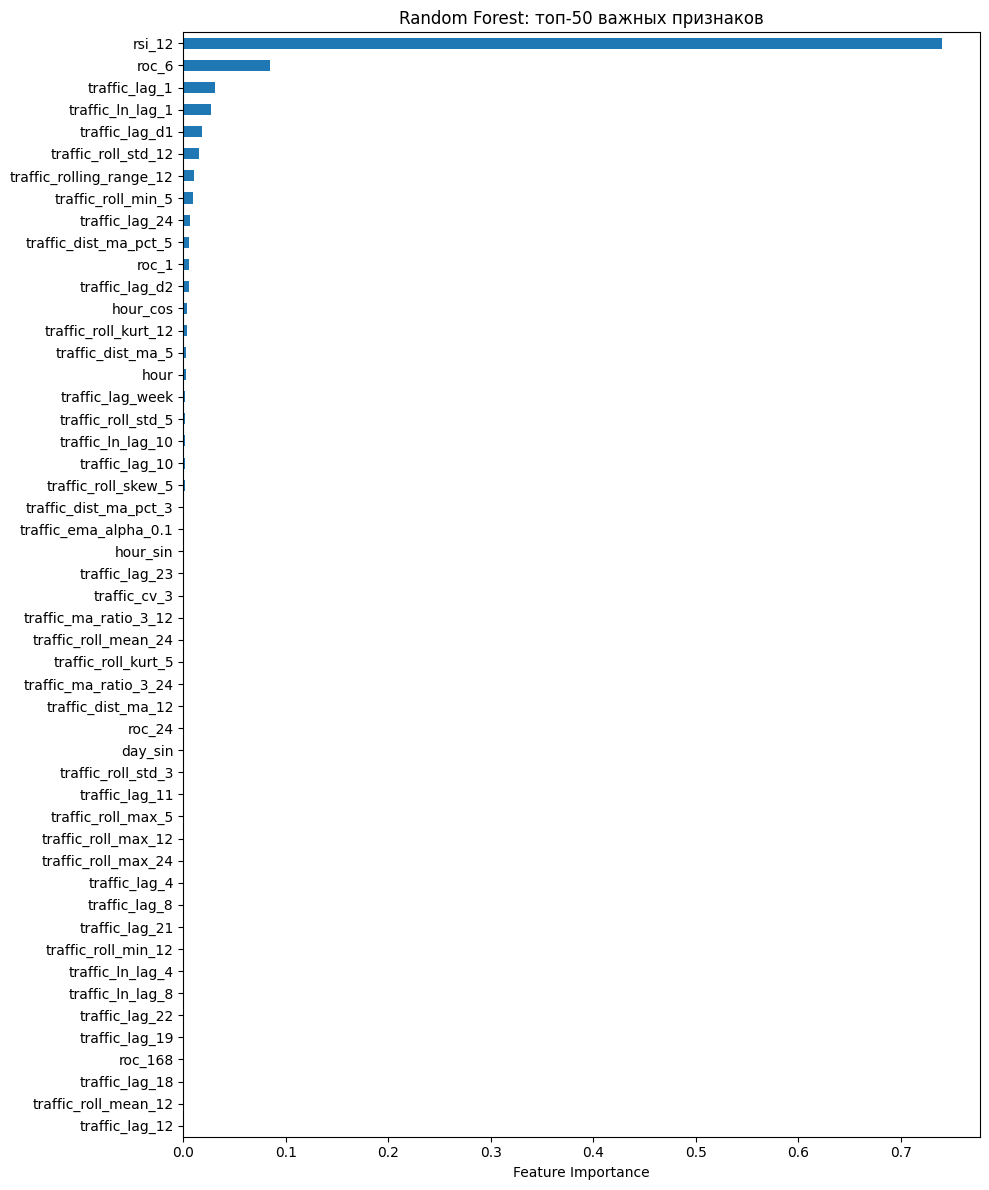

In [117]:
plt.figure(figsize=(10, 12))
importances.head(50).sort_values().plot(kind='barh')
plt.title(f"Random Forest: топ-{50} важных признаков")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

In [118]:
selected_top_n = importances.head(50).index.tolist()

X_final = X_step2[selected_top_n]
print(f"\nИтоговый датасет: {X_final.shape}")


Итоговый датасет: (20355, 50)


In [119]:
report = {
    'Исходное количество признаков': X_step0.shape[1],
    'После фильтра дисперсии': X_step1.shape[1],
    'После фильтра корреляции': X_step2.shape[1],
    'После RF отбора (топ 50)': X_final.shape[1],
}

for step, count in report.items():
    print(f"{step:45s}: {count}")

Исходное количество признаков                : 235
После фильтра дисперсии                      : 220
После фильтра корреляции                     : 145
После RF отбора (топ 50)                     : 50


## Forward selection (самостоятельная реализация)

In [89]:
def my_forward_selection(estimator, X, y, tscv, max_features=25, min_improvement_pct=0.5, scoring='r2'):
    selected_features = []
    remaining_features = list(X.columns)
    best_score = -np.inf
    
    print(f"Старт Forward Selection (Порог: {min_improvement_pct}%, Макс. фич: {max_features})")
    
    while len(selected_features) < max_features and remaining_features:
        scores_with_candidates = []
        
        # Тестируем добавление каждого оставшегося признака
        for feature in remaining_features:
            candidate_set = selected_features + [feature]
            score = np.mean(cross_val_score(estimator, X[candidate_set], y, cv=tscv, scoring=scoring))
            scores_with_candidates.append((score, feature))
            
        # Находим лучший признак на этом шаге
        scores_with_candidates.sort(reverse=True)
        best_candidate_score, best_candidate_feature = scores_with_candidates[0]
        
        # Считаем улучшение относительно предыдущего шага
        if len(selected_features) == 0:
            improvement = 100.0
        else:
            improvement = ((best_candidate_score - best_score) / (abs(best_score) + 1e-8)) * 100
            
        # Проверка критерия остановки
        if improvement < min_improvement_pct and len(selected_features) > 0:
            print(f"Остановка: улучшение ({improvement:.3f}%) меньше порога в {min_improvement_pct}%")
            break
            
        best_score = best_candidate_score
        selected_features.append(best_candidate_feature)
        remaining_features.remove(best_candidate_feature)
        
        print(f"Шаг {len(selected_features)}: Добавлен [{best_candidate_feature}] | Score: {best_score:.4f} (+{improvement:.3f}%)")
        
    print(f"Итог: Отобрано признаков: {len(selected_features)}\n")
    return selected_features

## Backward selection (самостоятельная реализация)

In [90]:
def my_backward_selection(estimator, X, y, tscv, min_features=10, max_drop_pct=1.0, scoring='r2'):
    selected_features = list(X.columns)
    
    # Считаем базовый скор на всех признаках
    best_score = np.mean(cross_val_score(estimator, X[selected_features], y, cv=tscv, scoring=scoring))
    print(f"Старт Backward Selection")
    print(f"Стартовый Score на всех признаках ({len(selected_features)} шт): {best_score:.4f}\n")
    
    while len(selected_features) > min_features:
        scores_with_candidates = []
        
        # Тестируем удаление каждого признака по очереди
        for feature in selected_features:
            candidate_set = [f for f in selected_features if f != feature]
            score = np.mean(cross_val_score(estimator, X[candidate_set], y, cv=tscv, scoring=scoring))
            scores_with_candidates.append((score, feature))

        # Отбираем признак после удаления которого был наилучший скор
        scores_with_candidates.sort(reverse=True)
        best_candidate_score, feature_to_remove = scores_with_candidates[0]
        
        # Считаем ухудшение относительно предыдущего шага
        drop_pct = ((best_score - best_candidate_score) / (abs(best_score) + 1e-8)) * 100
        
        # Проверка критерия остановки
        if drop_pct > max_drop_pct:
            print(f"Остановка: ухудшение метрики ({drop_pct:.3f}%) превысило порог в {max_drop_pct}%")
            break
            
        best_score = best_candidate_score
        selected_features.remove(feature_to_remove)
        
        print(f"Шаг {len(X.columns) - len(selected_features)}: Удален [{feature_to_remove}] | Текущий Score: {best_score:.4f} (Изменение: {-drop_pct:.3f}%)")
        
    print(f"Итог: Оставлено признаков: {len(selected_features)}\n")
    return selected_features

In [76]:
xgb = XGBRegressor(n_estimators=50, max_depth=5, n_jobs=-1, random_state=42)
ridge = make_pipeline(StandardScaler(), Ridge())

tscv = TimeSeriesSplit(n_splits=5)

xgb_forward_features = my_forward_selection(
    estimator=xgb, 
    X=X_final, 
    y=y_final, 
    tscv=tscv,
    max_features=20, 
    min_improvement_pct=0.5, 
    scoring='r2'
)

xgb_backward_features = my_backward_selection(
    estimator=xgb, 
    X=X_final, 
    y=y_final, 
    tscv=tscv,
    min_features=10, 
    max_drop_pct=1.0, 
    scoring='r2'
)

ridge_forward_features = my_forward_selection(
    estimator=ridge, 
    X=X_final, 
    y=y_final, 
    tscv=tscv,
    max_features=20, 
    min_improvement_pct=0.5, 
    scoring='r2'
)

ridge_backward_features = my_backward_selection(
    estimator=ridge, 
    X=X_final, 
    y=y_final, 
    tscv=tscv,
    min_features=10, 
    max_drop_pct=1.0, 
    scoring='r2'
)

Старт Forward Selection (Порог: 0.5%, Макс. фич: 20)
Шаг 1: Добавлен [traffic_ln_lag_1] | Score: 0.8536 (+100.000%)
Шаг 2: Добавлен [hour] | Score: 0.9761 (+14.353%)
Остановка: улучшение (0.469%) меньше порога в 0.5%
Итог: Отобрано признаков: 2

Старт Backward Selection
Стартовый Score на всех признаках (50 шт): 0.9787

Шаг 1: Удален [rsi_12] | Текущий Score: 0.9796 (Изменение: 0.089%)
Шаг 2: Удален [traffic_dist_ma_12] | Текущий Score: 0.9799 (Изменение: 0.036%)
Шаг 3: Удален [traffic_roll_kurt_12] | Текущий Score: 0.9804 (Изменение: 0.042%)
Шаг 4: Удален [traffic_cv_3] | Текущий Score: 0.9806 (Изменение: 0.023%)
Шаг 5: Удален [traffic_ln_lag_8] | Текущий Score: 0.9806 (Изменение: -0.000%)
Шаг 6: Удален [traffic_ln_lag_4] | Текущий Score: 0.9806 (Изменение: -0.000%)
Шаг 7: Удален [traffic_ln_lag_10] | Текущий Score: 0.9806 (Изменение: -0.000%)
Шаг 8: Удален [traffic_ln_lag_1] | Текущий Score: 0.9806 (Изменение: -0.000%)
Шаг 9: Удален [traffic_roll_mean_24] | Текущий Score: 0.9806 (Изм

In [87]:
print(f'Признаки отобранные Forward selection XGBoost: ')
print(*xgb_forward_features, sep='\n')
print("--------------------------")
print(f'Признаки отобранные Backward selection XGBoost: ')
print(*xgb_backward_features, sep='\n')
print("--------------------------")
print(f'Признаки отобранные Forward selection Ridge: ')
print(*ridge_forward_features, sep='\n')
print("--------------------------")
print(f'Признаки отобранные Backward selection Ridge: ')
print(*ridge_backward_features, sep='\n')

Признаки отобранные Forward selection XGBoost: 
traffic_ln_lag_1
hour
--------------------------
Признаки отобранные Backward selection XGBoost: 
traffic_lag_1
traffic_lag_d1
traffic_roll_min_5
traffic_lag_24
hour_cos
hour
roc_24
day_sin
traffic_lag_22
traffic_lag_12
--------------------------
Признаки отобранные Forward selection Ridge: 
traffic_lag_1
traffic_dist_ma_pct_3
traffic_lag_23
traffic_roll_min_12
traffic_lag_4
--------------------------
Признаки отобранные Backward selection Ridge: 
traffic_roll_min_5
traffic_lag_d2
traffic_roll_std_5
traffic_lag_10
traffic_dist_ma_pct_3
traffic_lag_23
traffic_cv_3
traffic_dist_ma_12
traffic_lag_8
traffic_roll_min_12


In [96]:
from collections import Counter

frequency_dict = Counter(xgb_forward_features) + Counter(xgb_backward_features) + Counter(ridge_forward_features) + Counter(ridge_backward_features)

frequency_dict

Counter({'hour': 2,
         'traffic_lag_1': 2,
         'traffic_roll_min_5': 2,
         'traffic_dist_ma_pct_3': 2,
         'traffic_lag_23': 2,
         'traffic_roll_min_12': 2,
         'traffic_ln_lag_1': 1,
         'traffic_lag_d1': 1,
         'traffic_lag_24': 1,
         'hour_cos': 1,
         'roc_24': 1,
         'day_sin': 1,
         'traffic_lag_22': 1,
         'traffic_lag_12': 1,
         'traffic_lag_4': 1,
         'traffic_lag_d2': 1,
         'traffic_roll_std_5': 1,
         'traffic_lag_10': 1,
         'traffic_cv_3': 1,
         'traffic_dist_ma_12': 1,
         'traffic_lag_8': 1})

Решено провести обучение каждой из 3-х моделей на 4 полученных поднаборах признаков

In [101]:
X_final_xgb_forward    = X_final[xgb_forward_features]
X_final_xgb_backward   = X_final[xgb_backward_features]
X_final_ridge_forward  = X_final[ridge_forward_features]
X_final_ridge_backward = X_final[ridge_backward_features]

# Обучение моделей на отобранных признаках

## Train (cross-val) / Test split

In [242]:
tr_end = int(0.7 * len(y_final))
vl_end = int(0.85 * len(y_final))

# xgb_forward_features
X_train_xgb_forward    = X_final_xgb_forward.iloc[:tr_end]
X_val_xgb_forward      = X_final_xgb_forward.iloc[tr_end:vl_end]
X_test_xgb_forward     = X_final_xgb_forward.iloc[vl_end:]

# xgb_backward_features
X_train_xgb_backward   = X_final_xgb_backward.iloc[:tr_end]
X_val_xgb_backward     = X_final_xgb_backward.iloc[tr_end:vl_end]
X_test_xgb_backward    = X_final_xgb_backward.iloc[vl_end:]

# ridge_forward_features
X_train_ridge_forward  = X_final_ridge_forward.iloc[:tr_end]
X_val_ridge_forward    = X_final_ridge_forward.iloc[tr_end:vl_end]
X_test_ridge_forward   = X_final_ridge_forward.iloc[vl_end:]

# ridge_backward_features
X_train_ridge_backward = X_final_ridge_backward.iloc[:tr_end]
X_val_ridge_backward   = X_final_ridge_backward.iloc[tr_end:vl_end]
X_test_ridge_backward  = X_final_ridge_backward.iloc[vl_end:]

y_train = y_final.iloc[:tr_end]
y_val = y_final.iloc[tr_end:vl_end]
y_test = y_final.iloc[vl_end:]
date_time_for_val = X_date_time[tr_end:vl_end]
date_time_for_test = X_date_time[vl_end:]

In [292]:
def plot_res(predictions, date_time_for_test, y_test):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, (pred, title) in enumerate(predictions):
        ax = axes[i]
        
        ax.plot(date_time_for_test[:24*7], y_test[:24*7], label='Факт', color='black', alpha=0.6)
        ax.plot(date_time_for_test[:24*7], pred[:24*7], label='Предсказание', color='red', linestyle='--')
        
        ax.set_title(title)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        
        plt.setp(ax.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()

## Линейная регрессия

### Кросс-валидация

In [293]:
ridge = make_pipeline(StandardScaler(), Ridge())

tscv = TimeSeriesSplit(n_splits=5)
params = {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

grid_ridge = GridSearchCV(ridge, params, cv=tscv, scoring='r2')

grid_ridge.fit(X_train_xgb_forward, y_train)
ridge_preds_xgb_forward = grid_ridge.predict(X_test_xgb_forward)

grid_ridge.fit(X_train_xgb_backward, y_train)
ridge_preds_xgb_backward = grid_ridge.predict(X_test_xgb_backward)

grid_ridge.fit(X_train_ridge_forward, y_train)
ridge_preds_ridge_forward = grid_ridge.predict(X_test_ridge_forward)

grid_ridge.fit(X_train_ridge_backward, y_train)
ridge_preds_ridge_backward = grid_ridge.predict(X_test_ridge_backward)

### Результаты

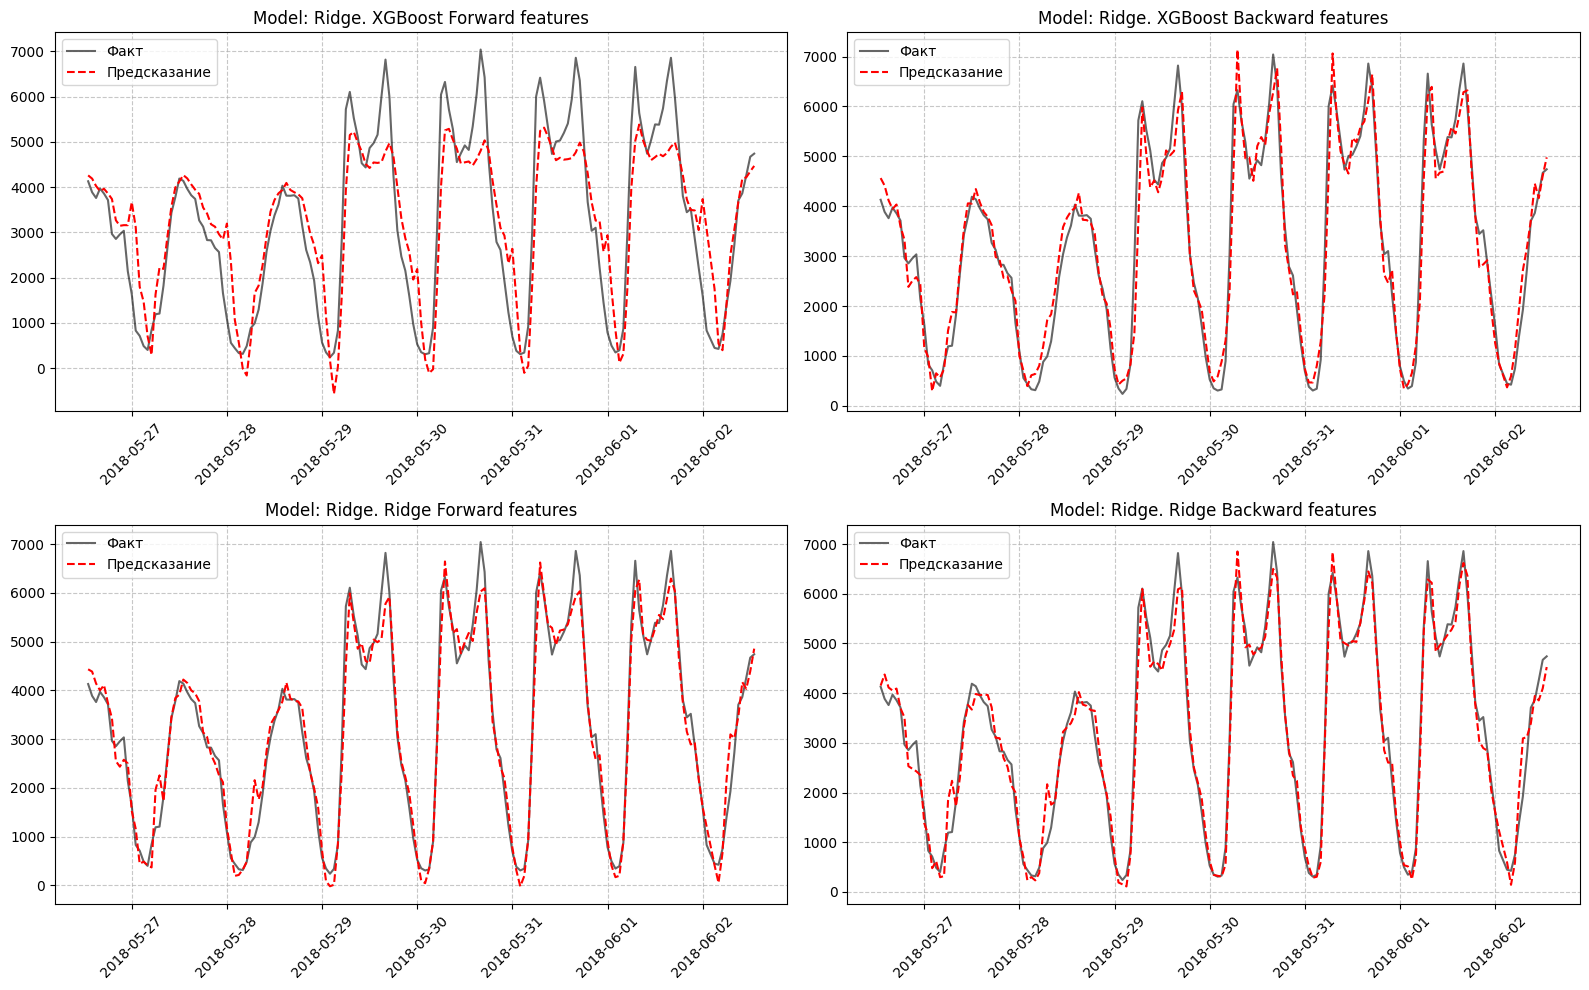

In [294]:
predictions_ridge = [
    (ridge_preds_xgb_forward, "Model: Ridge. XGBoost Forward features"),
    (ridge_preds_xgb_backward, "Model: Ridge. XGBoost Backward features"),
    (ridge_preds_ridge_forward, "Model: Ridge. Ridge Forward features"),
    (ridge_preds_ridge_backward, "Model: Ridge. Ridge Backward features")
]
plot_res(predictions_ridge, date_time_for_test, y_test)

## Gradient Boosting Regressor

### Кросс-валидация

In [245]:
xgb = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=tscv,
    n_jobs=-1,
)

grid_xgb.fit(X_train_xgb_forward, y_train)
xgb_preds_xgb_forward = grid_xgb.predict(X_test_xgb_forward)

grid_xgb.fit(X_train_xgb_backward, y_train)
xgb_preds_xgb_backward = grid_xgb.predict(X_test_xgb_backward)

grid_xgb.fit(X_train_ridge_forward, y_train)
xgb_preds_ridge_forward = grid_xgb.predict(X_test_ridge_forward)

grid_xgb.fit(X_train_ridge_backward, y_train)
xgb_preds_ridge_backward = grid_xgb.predict(X_test_ridge_backward)

### Результаты

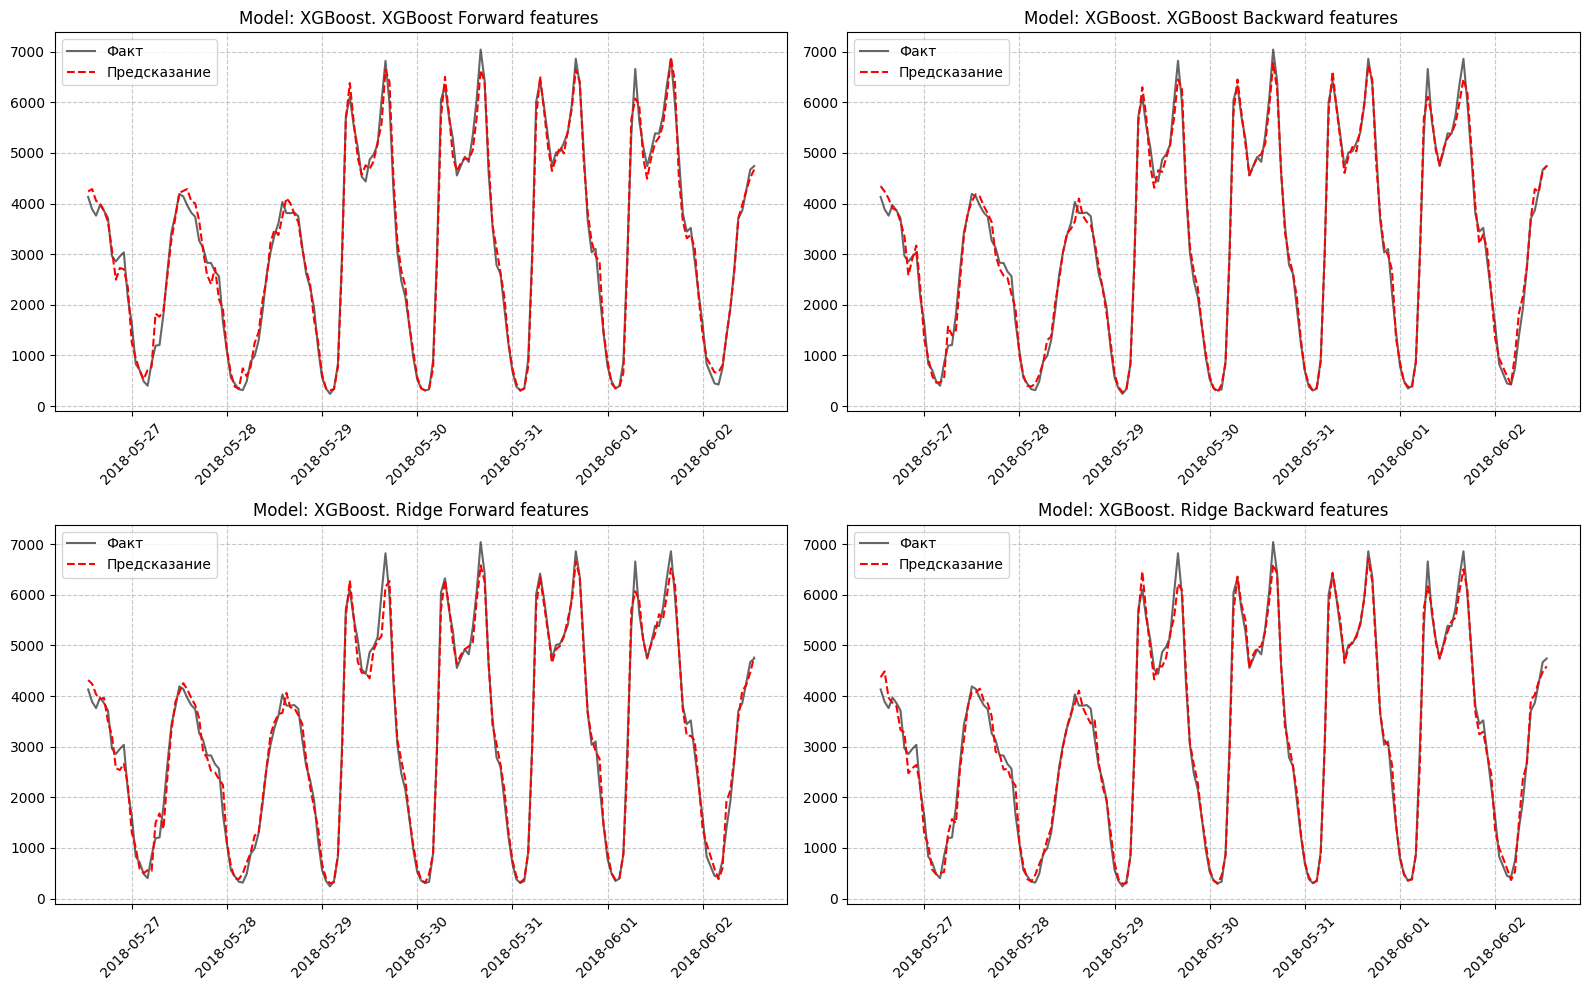

In [277]:
predictions_xgb = [
    (xgb_preds_xgb_forward, "Model: XGBoost. XGBoost Forward features"),
    (xgb_preds_xgb_backward, "Model: XGBoost. XGBoost Backward features"),
    (xgb_preds_ridge_forward, "Model: XGBoost. Ridge Forward features"),
    (xgb_preds_ridge_backward, "Model: XGBoost. Ridge Backward features")
]
plot_res(predictions_xgb, date_time_for_test, y_test)

## LSTM

In [197]:
class TrafficDataset(Dataset):
    def __init__(self, X, y, window_size):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
        self.window_size = window_size

    def __len__(self):
        return len(self.X) - self.window_size

    def __getitem__(self, idx):
        X_window = self.X[idx : idx + self.window_size]
        y_target = self.y[idx + self.window_size]

        return X_window, y_target

In [198]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x, _ = self.lstm(x)
        last_time_step = x[:, -1, :]
        y = self.output_layer(last_time_step)
        return y.squeeze(-1)

### Кросс-валидация (на одном из наборов признаков, на всех долго)

In [250]:
Xraw = X_train_xgb_forward.to_numpy()
X_test_raw = X_test_xgb_forward.to_numpy()
yraw = y_train.to_numpy()

In [235]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "window_size": [10, 20, 30, 50],
    "batch_size": [16, 32, 64],
    "learning_rate": [0.001, 0.01, 0.1]
}

all_configs = list(product(
    param_grid["window_size"],
    param_grid["batch_size"],
    param_grid["learning_rate"]
))

def train_one_fold(X_train, y_train, X_val, y_val, window_size, batch_size, learning_rate, epochs=20):
    train_dataset = TrafficDataset(X_train, y_train, window_size)
    val_dataset = TrafficDataset(X_val,y_val,window_size)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
    
    model = LSTMModel(input_size=X_train.shape[1], hidden_size=64, num_layers=2, output_size=1)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            epoch_loss += loss.item() * X_batch.size(0)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{20} | Loss: {epoch_loss / len(train_loader.dataset):.4f}")

    model.eval()
    losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            losses.append(loss.item())

    return np.mean(losses)

In [237]:
results = []

for window_size, batch_size, lr in all_configs:
    print(f"Конфигурация: window={window_size}, batch={batch_size}, lr={lr}")
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(Xraw)):
        print(f"\nFold {fold_idx + 1}")
        x_mean = Xraw[train_idx].mean(axis=0)
        x_std  = Xraw[train_idx].std(axis=0)
    
        y_mean = yraw[train_idx].mean()
        y_std  = yraw[train_idx].std()
    
        x_std[x_std == 0] = 1.0
        y_std = 1.0 if y_std == 0 else y_std
        
        X_train_fold = (Xraw[train_idx] - x_mean) / x_std
        X_val_fold   = (Xraw[val_idx] - x_mean) / x_std
    
        y_train_fold = (yraw[train_idx] - y_mean) / y_std
        y_val_fold   = (yraw[val_idx] - y_mean) / y_std

        score = train_one_fold(X_train_fold, y_train_fold, X_val_fold, y_val_fold, window_size, batch_size, lr)

        fold_scores.append(score)

    mean_score = np.mean(fold_scores)

    results.append({
        "window_size": window_size,
        "batch_size": batch_size,
        "learning_rate": lr,
        "cv_score": mean_score
    })
    print(f"\nCV score = {mean_score:.6f}")

Конфигурация: window=10, batch=16, lr=0.001

Fold 1
Эпоха 1/20 | Loss: 0.4398
Эпоха 2/20 | Loss: 0.2441
Эпоха 3/20 | Loss: 0.2019
Эпоха 4/20 | Loss: 0.1686
Эпоха 5/20 | Loss: 0.1288
Эпоха 6/20 | Loss: 0.1066
Эпоха 7/20 | Loss: 0.0951
Эпоха 8/20 | Loss: 0.0879
Эпоха 9/20 | Loss: 0.0779
Эпоха 10/20 | Loss: 0.0742
Эпоха 11/20 | Loss: 0.0749
Эпоха 12/20 | Loss: 0.0662
Эпоха 13/20 | Loss: 0.0615
Эпоха 14/20 | Loss: 0.0620
Эпоха 15/20 | Loss: 0.0576
Эпоха 16/20 | Loss: 0.0553
Эпоха 17/20 | Loss: 0.0548
Эпоха 18/20 | Loss: 0.0552
Эпоха 19/20 | Loss: 0.0538
Эпоха 20/20 | Loss: 0.0507

Fold 2
Эпоха 1/20 | Loss: 0.3194
Эпоха 2/20 | Loss: 0.1743
Эпоха 3/20 | Loss: 0.1139
Эпоха 4/20 | Loss: 0.0928
Эпоха 5/20 | Loss: 0.0809
Эпоха 6/20 | Loss: 0.0763
Эпоха 7/20 | Loss: 0.0712
Эпоха 8/20 | Loss: 0.0675
Эпоха 9/20 | Loss: 0.0632
Эпоха 10/20 | Loss: 0.0623
Эпоха 11/20 | Loss: 0.0611
Эпоха 12/20 | Loss: 0.0588
Эпоха 13/20 | Loss: 0.0582
Эпоха 14/20 | Loss: 0.0566
Эпоха 15/20 | Loss: 0.0559
Эпоха 16/20 |

In [240]:
results_df = pd.DataFrame(results)

best_row = results_df.loc[
    results_df["cv_score"].idxmin()
]

print(best_row)

window_size      30.000000
batch_size       16.000000
learning_rate     0.010000
cv_score          0.048633
Name: 19, dtype: float64


### Обучение

In [260]:
WINDOW_SIZE = 30
BATCH_SIZE = 16
LEARNING_RATE = 0.01
HIDDEN_SIZE = 64
EPOCHS = 100

In [278]:
features_splits = [
    [X_train_xgb_forward,
    X_val_xgb_forward,
    X_test_xgb_forward],
    
    [X_train_xgb_backward,
    X_val_xgb_backward,
    X_test_xgb_backward],
    
    [X_train_ridge_forward,
    X_val_ridge_forward,
    X_test_ridge_forward],
    
    [X_train_ridge_backward,
    X_val_ridge_backward,
    X_test_ridge_backward],
]
names = ['XGBoost Forward features', 'XGBoost Backward features', 'Ridge Forward features', 'Ridge Backward features']

In [285]:
def train_one_model(model, X_train, X_val, y_train, y_val, window_size, batch_size, learning_rate, epochs, patience=5):
    train_dataset = TrafficDataset(X_tn, y_tn, window_size)
    val_dataset   = TrafficDataset(X_vn, y_vn, window_size)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader    = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_model_state = None
    bad_epochs = 0

    history = {
        "epoch_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            epoch_loss += loss.item() * X_batch.size(0)
            loss.backward()
            optimizer.step()
        epoch_loss /= len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)
        
        history["epoch_loss"].append(epoch_loss)
        history["val_loss"].append(val_loss)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"train={epoch_loss:.4f} | val={val_loss:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_state)

    return model, history

In [286]:
yraw_train = y_train.to_numpy()
yraw_val   = y_val.to_numpy()
yraw_test  = y_test.to_numpy()

predictions_lstm = []
histories_lstm = []

for i, split in enumerate(features_splits):
    print(f"Train model on {names[i]}")
    X_train = split[0].to_numpy()
    X_val   = split[1].to_numpy()
    X_test  = split[2].to_numpy()
    
    x_mean = X_train.mean(axis=0)
    x_std  = X_train.std(axis=0)
    x_std[x_std == 0] = 1.0

    y_mean = yraw_train.mean()
    y_std  = yraw_train.std()
    y_std = 1.0 if y_std == 0 else y_std
    
    X_tn = (X_train - x_mean) / x_std
    X_vn = (X_val - x_mean) / x_std
    X_ts = (X_test  - x_mean) / x_std

    y_tn = (yraw_train - y_mean) / y_std
    y_vn = (yraw_val - y_mean) / y_std
    model = LSTMModel(input_size=X_tn.shape[1], hidden_size=HIDDEN_SIZE, num_layers=2, output_size=1)
    
    model, history = train_one_model(model, X_tn, X_vn, y_tn, y_vn, WINDOW_SIZE, BATCH_SIZE, LEARNING_RATE, EPOCHS)

    histories_lstm.append((history, f"Model: LSTM. {names[i]}"))

    model.eval()
    test_dataset = TrafficDataset(X_ts, yraw_test, WINDOW_SIZE)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    preds = []

    with torch.no_grad():
        for X_batch, _ in test_loader:
            pred = model(X_batch)
            preds.append(pred.numpy())

    preds = np.concatenate(preds)
    
    preds = preds * y_std + y_mean

    predictions_lstm.append((preds, f"Model: LSTM. {names[i]}"))

Train model on XGBoost Forward features
Epoch 1/100 | train=0.1350 | val=0.1261
Epoch 2/100 | train=0.0690 | val=0.1048
Epoch 3/100 | train=0.0587 | val=0.1098
Epoch 4/100 | train=0.0539 | val=0.1127
Epoch 5/100 | train=0.0485 | val=0.0820
Epoch 6/100 | train=0.0477 | val=0.0826
Epoch 7/100 | train=0.0484 | val=0.0742
Epoch 8/100 | train=0.0479 | val=0.0732
Epoch 9/100 | train=0.0422 | val=0.0736
Epoch 10/100 | train=0.0434 | val=0.0700
Epoch 11/100 | train=0.0424 | val=0.0863
Epoch 12/100 | train=0.0415 | val=0.0615
Epoch 13/100 | train=0.0414 | val=0.0602
Epoch 14/100 | train=0.0396 | val=0.0684
Epoch 15/100 | train=0.0396 | val=0.0548
Epoch 16/100 | train=0.0403 | val=0.0743
Epoch 17/100 | train=0.0376 | val=0.0508
Epoch 18/100 | train=0.0367 | val=0.0589
Epoch 19/100 | train=0.0365 | val=0.0538
Epoch 20/100 | train=0.0370 | val=0.0651
Epoch 21/100 | train=0.0399 | val=0.0504
Epoch 22/100 | train=0.0342 | val=0.0589
Epoch 23/100 | train=0.0380 | val=0.0557
Epoch 24/100 | train=0.037

### Результаты

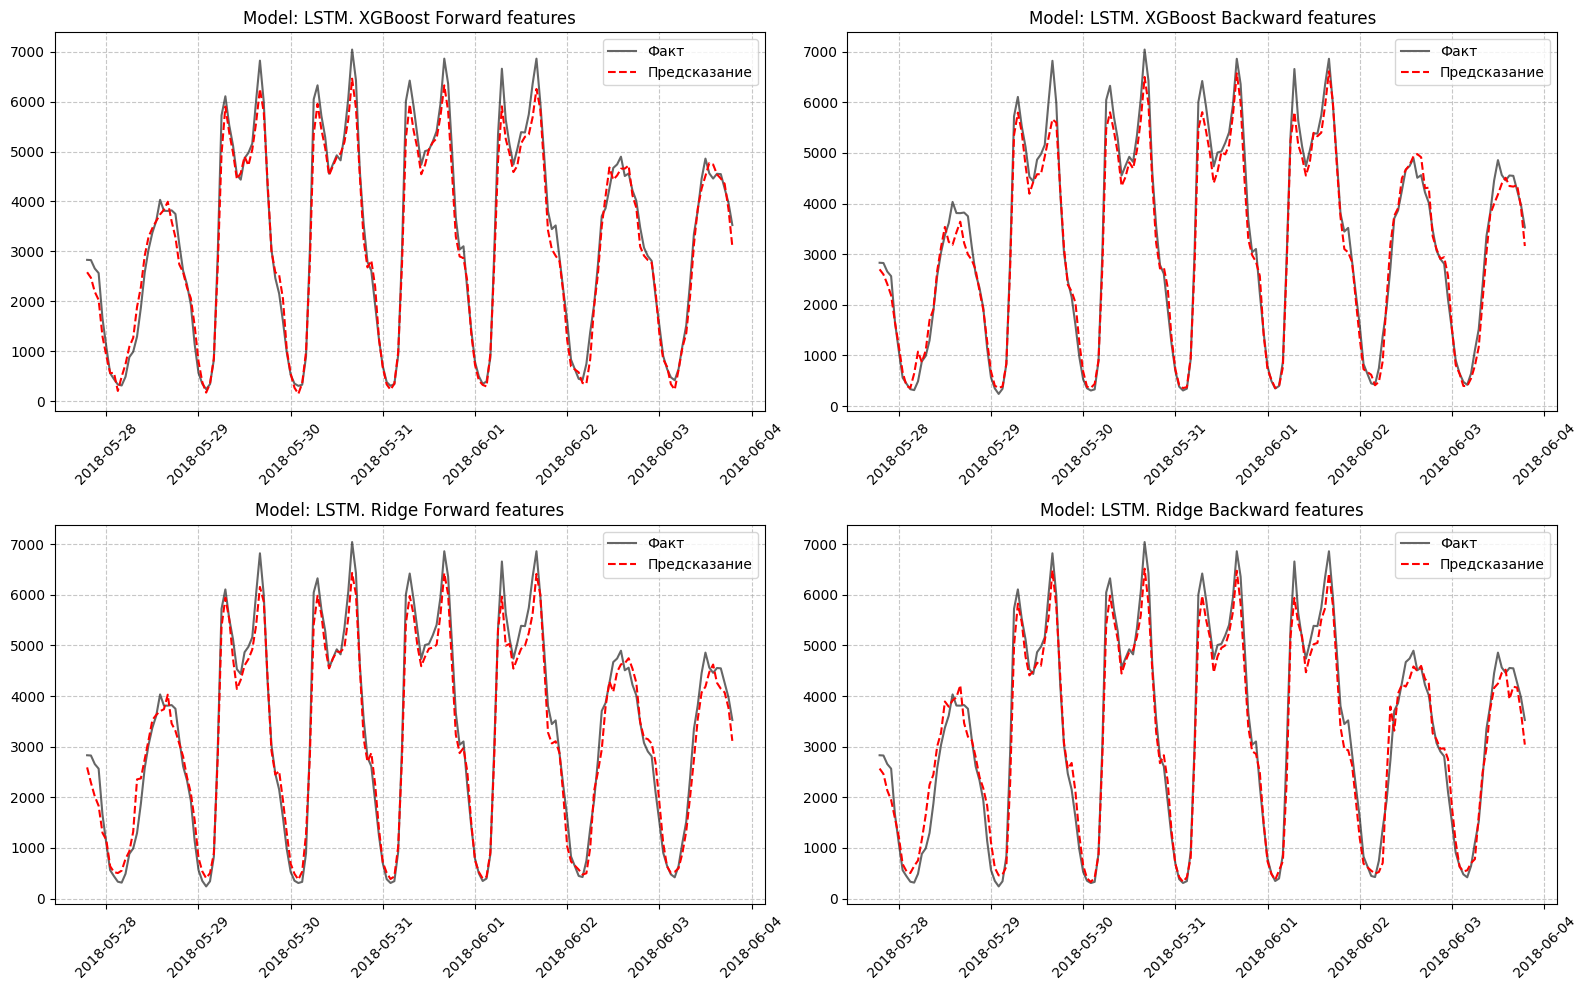

In [313]:
plot_res(predictions_lstm, date_time_for_test[WINDOW_SIZE:], y_test[WINDOW_SIZE:])

### Графики сходимости

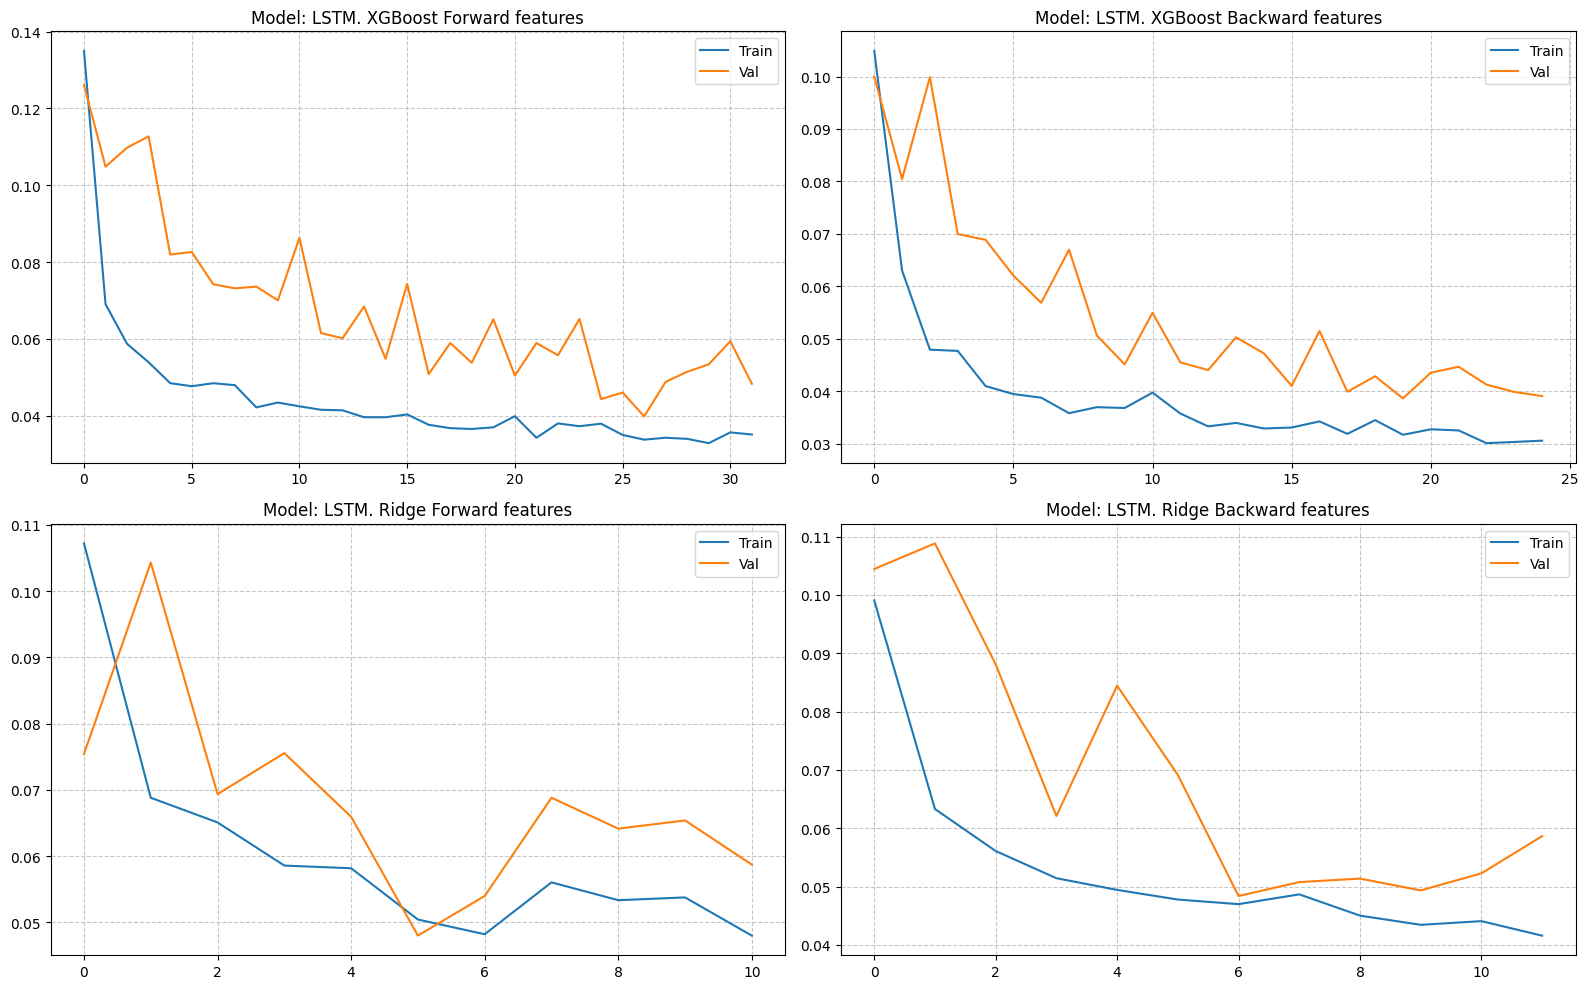

In [320]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (losses, name) in enumerate(histories_lstm):
    ax = axes[i]
    
    ax.plot(losses["epoch_loss"], label='Train')
    ax.plot(losses["val_loss"], label='Val')
    
    ax.set_title(name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Метрики

In [322]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-8
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
    )

def evaluate_model(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

def align(y_true, y_pred):
    n = min(len(y_true), len(y_pred))
    return y_true[-n:], y_pred[-n:]

In [325]:
results_table = []

for preds, name in predictions_ridge:

    y_true_aligned, preds_aligned = align(y_test, preds)

    metrics = evaluate_model(y_true_aligned, preds_aligned)

    metrics["Model"] = name

    results_table.append(metrics)

for preds, name in predictions_xgb:

    y_true_aligned, preds_aligned = align(y_test, preds)

    metrics = evaluate_model(y_true_aligned, preds_aligned)

    metrics["Model"] = name

    results_table.append(metrics)

for preds, name in predictions_lstm:

    y_true_aligned, preds_aligned = align(y_test, preds)

    metrics = evaluate_model(y_true_aligned, preds_aligned)

    metrics["Model"] = name

    results_table.append(metrics)

In [328]:
df_results = pd.DataFrame(results_table)

df_results = df_results[[
    "Model",
    "MAE",
    "RMSE",
    "MAPE",
    "SMAPE",
    "R2"
]]

df_results.sort_values(by=["R2", "MAE"], ascending=[False, True])

,Model,MAE,RMSE,MAPE,SMAPE,R2
5,Model: XGBoost. XGBoost Backward features,131.131989,196.805970,5.290694,5.233603,0.989637
7,Model: XGBoost. Ridge Backward features,147.586868,218.757821,6.212403,6.089644,0.987197
6,Model: XGBoost. Ridge Forward features,159.256287,231.287269,6.811430,6.559765,0.985688
4,Model: XGBoost. XGBoost Forward features,166.958801,236.596084,7.893765,7.450646,0.985023
9,Model: LSTM. XGBoost Backward features,201.723648,287.782809,8.024615,7.926312,0.977949
8,Model: LSTM. XGBoost Forward features,221.867432,305.490129,9.400541,9.913275,0.975151
10,Model: LSTM. Ridge Forward features,232.308350,316.357874,11.285547,10.580802,0.973352
3,Model: Ridge. Ridge Backward features,236.263412,328.844228,12.272835,12.360381,0.971068
11,Model: LSTM. Ridge Backward features,250.520401,344.482470,12.457538,11.584465,0.968403
2,Model: Ridge. Ridge Forward features,269.594040,367.880310,15.402579,17.158669,0.963791


Лучшая модель по всем метрикам - XGBoost при отборе признаков:XGBoost Backward features

## График предсказаний и фактических значений для лучшей модели

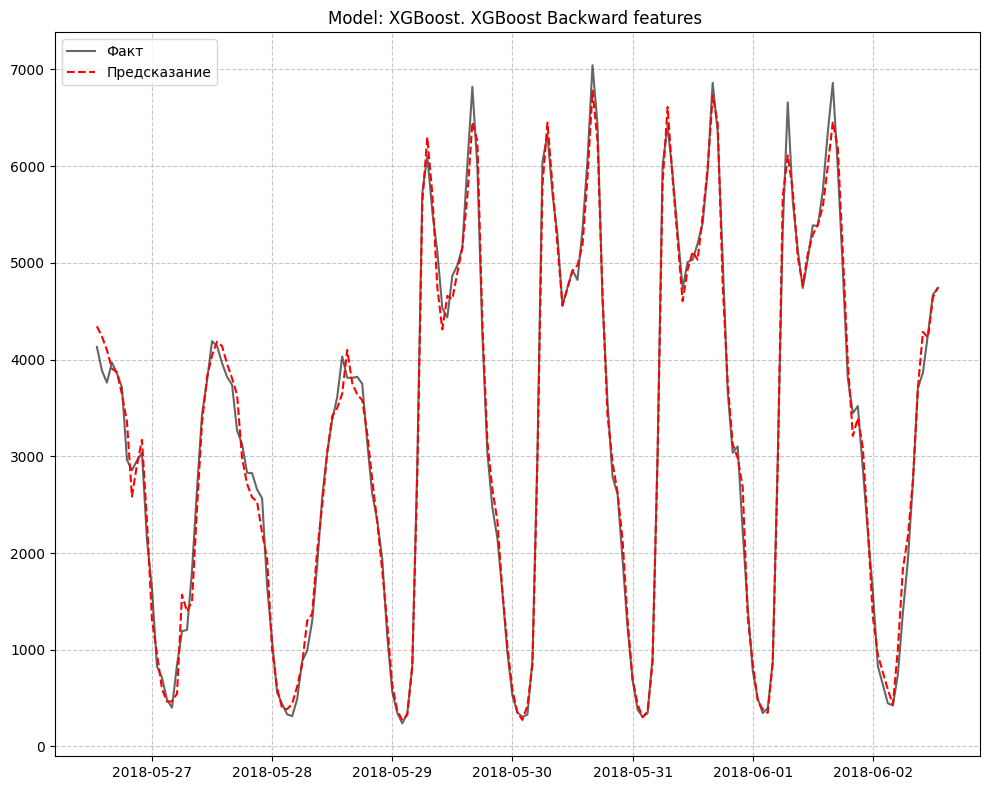

In [335]:
plt.plot(date_time_for_test[:24*7], y_test[:24*7], label='Факт', color='black', alpha=0.6)
plt.plot(date_time_for_test[:24*7], predictions_xgb[1][0][:24*7], label='Предсказание', color='red', linestyle='--')

plt.title(predictions_xgb[1][1])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()